[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIPI-590-XAI/Duke-AI-XAI/blob/main/assignments/xai_decathlon.ipynb)

# XAI Decathlon: Round 1 Individual Method Trial

In this lab, each student works with **one assigned explainability method** and tries to use it across ten explanation events.

The notebook gives you:

- Two trained target models: one tabular model and one image model.
- Ten event prompts with ready-to-use model objects, data objects, and assigned cases.
- A markdown results table to fill in as you go.
- A final model-profile prompt for summarizing what your method can and cannot support.

The notebook does **not** implement LIME, SHAP, PDP, ALE, Grad-CAM, Score-CAM, saliency, counterfactuals, or any other explanation method for you. That is the challenge.

**Estimated time:** 60-75 minutes  
**Format:** individual method trial  
**Deliverable:** a completed results table plus a short model profile


## Core Lesson

Different explanation methods answer different kinds of questions.

Your job is to find out where your assigned method is useful, where it is only partially useful, and where it simply does not fit the task. A method can earn a strong score for saying something clear and justified, including: "this method cannot answer this event question."

This notebook is intentionally only the individual round. Later, you may compare results with classmates who used different methods.


## Scoring Rules

For each event, assign your method one medal:

- **Gold:** directly answers the event question with convincing evidence.
- **Silver:** gives useful partial evidence, but another method or assumption is needed.
- **Bronze:** gives weak, indirect, or fragile evidence.
- **DNF:** does not finish: the method is mismatched, misleading, or not usable for the event.

A pretty visualization is not automatically a medal. Score the method based on whether it answers the event question.


## The Ten Events

| Event | Question |
|---|---|
| 1. Most Important Feature | What variable most strongly influences the tabular model's predictions? |
| 2. One Specific Prediction | Why did this individual tabular prediction occur? |
| 3. Dataset Bias or Shortcut | Is the image model relying on a spurious shortcut? |
| 4. Global Feature Effect | As one tabular feature changes, what happens to predictions? |
| 5. Compare Two Predictions | Why were two cases classified differently? |
| 6. Feature Interactions | Which tabular variables work together? |
| 7. Where Is the Model Looking? | What region of an image drives the prediction? |
| 8. Explain a Failure | Why did the model make this mistake? |
| 9. Estimate Trustworthiness | Should a human trust this prediction? |
| 10. Reverse Engineer Strategy | What strategy has each model learned? |

## Results Table

Edit this markdown cell as you work through the events. Keep each evidence claim short enough that someone else can understand what your method showed and why you assigned the medal.

**My assigned method:** Saliency maps (vanilla gradient and SmoothGrad on the image CNN). They cannot be applied to the tabular random forest, which has no usable input gradient.

| Event | Question | Medal | Evidence from my method | Limitations or notes |
|---|---|---|---|---|
| 1. Most Important Feature | What variable most strongly influences the tabular model's predictions? | DNF | Not applicable. The tabular model is a random forest with no usable input gradient (exact gradient is zero for 89% of continuous row/feature pairs, Event 6), so there is no saliency map to rank features with. | A finite-difference substitute (not saliency) ranks `debt_ratio` 0.071 > `zip_proxy` 0.058 > `recent_late_payments` 0.040 and agrees with impurity importance (rho 0.96); context only. Better fits: permutation importance, SHAP. |
| 2. One Specific Prediction | Why did this individual tabular prediction occur? | DNF | Not applicable. At a row the forest's gradient is zero or jumps with the step size, so there is no valid local saliency for row 718. | Substitute (context only): most sensitive to `recent_late_payments` (+0.121) and `zip_proxy` (+0.104); continuous slopes flip with step size (`savings_k` -0.033 / +0.006 / -0.052). Better fits: SHAP, LIME, counterfactuals. |
| 3. Dataset Bias or Shortcut | Is the image model relying on a spurious shortcut? | Gold | Yes, the marker. 37-41% of SmoothGrad mass is in the marker box (3.5% of pixels). On the 174 marker images, greying the top-4% salient pixels flips 100% (P 0.98 -> 0.035) vs 0% for random pixels; painting the box onto 146 marker-free images turns 0% predicted-square into 100%. Accuracy 0.494 on a balanced test set. | On marker-free images 66-69% of saliency sits on the shape although the model ignores it, so a map alone can suggest shape use; the painting test shows the missing marker decides. |
| 4. Global Feature Effect | As one tabular feature changes, what happens to predictions? | DNF | Not applicable. A saliency map is a local slope at one input and the forest has no gradient, so there is nothing to turn into a global effect curve. | A finite-difference substitute, integrated, reproduces partial dependence (corr 0.999 for `debt_ratio`), but that is partial dependence rebuilt by hand, not saliency. Better fits: PDP, ICE, ALE. |
| 5. Compare Two Predictions | Why were two cases classified differently? | Silver | Image pair only: `reference_square` (marker, P=0.986) has 31% of its saliency in the marker box vs 3% for `contrast_square` (0.065). Painting the marker onto the contrast square raises P(square) 0.065 -> 0.985; removing it from the reference lowers 0.986 -> 0.074. | The contrast map puts 73% on the shape, which does not decide the outcome, so the swap test (an intervention) is what confirms it. Tabular low/high pair not scored: saliency cannot be applied to the forest. |
| 6. Feature Interactions | Which tabular variables work together? | DNF | Not applicable. Saliency is first-order (one feature at a time) and the forest has no gradient. A second-order finite-difference substitute found no consistent interaction (top pair `debt_ratio` x `savings_k`, sign consistency 0.05). | Context only, not saliency. Better fits: SHAP interaction values, H-statistic, 2-D partial dependence. |
| 7. Where Is the Model Looking? | What region of an image drives the prediction? | Silver | In the 3 marker images 31-45% of SmoothGrad mass is in the marker box (3.5% of pixels). Greying the top 4% salient pixels flips P(square) 0.98 -> 0.02 (random pixels: 0.98). Maps depend on trained weights (rho -0.08 to -0.01 vs untrained CNN). | Misleading for the marker-free square: the map lights up the shape (72%) but greying it changes nothing (P(circle) 0.97). A local gradient cannot show that the absence of the marker drives the prediction. Maps are diffuse (about 48% background). |
| 8. Explain a Failure | Why did the model make this mistake? | Gold | Image failure (circle + marker, predicted square P=0.98): 43% of SmoothGrad mass in the marker box; greying only that box drops P(square) 0.98 -> 0.02 (random same-size box: 0.96). | Gold rests on the image failure. The tabular failure (row 1) alone would be DNF: saliency cannot be applied to the forest. |
| 9. Estimate Trustworthiness | Should a human trust this prediction? | Silver | Image only: do not trust the shortcut probe, 45% of its SmoothGrad mass is on the marker and 8% on the shape. SmoothGrad is stable under noise (rho 0.97-0.99 vs vanilla 0.80-0.88). | As an error detector saliency is weak: AUC 0.63 vs 0.77 for plain confidence. Marker-free images look shape-driven, which could wrongly reassure a human. Tabular half not scored. |
| 10. Reverse Engineer Strategy | What strategy has each model learned? | Silver | Image only: marker present -> 37-41% of saliency in the marker box and always predicted square; marker absent -> 66-69% on the shape yet always predicted circle (accuracy 0.49); the rule 'marker => square' matches the CNN on 100% of test images. | Saliency alone would suggest the CNN uses shape on marker-free images; a behavioural check was needed. Saliency cannot profile the tabular model (SHAP / partial dependence needed). |

*Tabular analyses are finite-difference substitutes, shown for context only and not scored as saliency. Numbers come from one run (seed 42, CPU); the CNN can train slightly differently on other hardware, so small values may shift but not the conclusions.*


In [1]:
#@title Setup
# Run this cell first. It imports only the libraries needed to create the target models.
# You may add your own XAI imports later in the "Your method implementation" section.

import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

SEED = 42
rng = np.random.default_rng(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


In [2]:
#@title Event guide helper
# This table points you to the model/data objects for each event.

EVENTS = [
    "1. Most important feature",
    "2. One specific prediction",
    "3. Dataset bias or shortcut",
    "4. Global feature effect",
    "5. Compare two predictions",
    "6. Feature interactions",
    "7. Where is the model looking?",
    "8. Explain a failure",
    "9. Estimate trustworthiness",
    "10. Reverse engineer strategy",
]

event_guide = pd.DataFrame({
    "event": EVENTS,
    "target": [
        "Tabular risk model",
        "Tabular risk model",
        "Image shortcut model",
        "Tabular risk model",
        "Tabular or image cases",
        "Tabular risk model",
        "Image shortcut model",
        "Tabular or image failure case",
        "Either target model",
        "Both target models",
    ],
    "primary_objects": [
        "risk_model, X_train, X_test, feature_names, predict_risk_proba",
        "tabular_local_case, X_test, predict_risk_proba",
        "image_shortcut_case, image_reference_case, test_imgs, predict_image_proba",
        "X_train, X_test, feature_names, predict_risk_proba",
        "tabular_low_case vs tabular_high_case, or assigned_image_cases",
        "X_train, X_test, feature_names, predict_risk_proba",
        "image_model, test_imgs, assigned_image_cases, show_image_case",
        "tabular_failure_case or image_failure_case",
        "assigned cases, predicted probabilities, explanation stability checks",
        "all model interfaces and prior event evidence",
    ],
    "question_type": [
        "global feature importance",
        "local prediction explanation",
        "shortcut or bias diagnosis",
        "global feature effect",
        "contrastive explanation",
        "interaction discovery",
        "spatial localization",
        "failure diagnosis",
        "trust and uncertainty judgment",
        "synthesis and model profiling",
    ],
})

event_guide


,event,target,primary_objects,question_type
0,1. Most important feature,Tabular risk model,"risk_model, X_train, X_test, feature_names, pr...",global feature importance
1,2. One specific prediction,Tabular risk model,"tabular_local_case, X_test, predict_risk_proba",local prediction explanation
2,3. Dataset bias or shortcut,Image shortcut model,"image_shortcut_case, image_reference_case, tes...",shortcut or bias diagnosis
3,4. Global feature effect,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",global feature effect
4,5. Compare two predictions,Tabular or image cases,"tabular_low_case vs tabular_high_case, or assi...",contrastive explanation
5,6. Feature interactions,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",interaction discovery
6,7. Where is the model looking?,Image shortcut model,"image_model, test_imgs, assigned_image_cases, ...",spatial localization
7,8. Explain a failure,Tabular or image failure case,tabular_failure_case or image_failure_case,failure diagnosis
8,9. Estimate trustworthiness,Either target model,"assigned cases, predicted probabilities, expla...",trust and uncertainty judgment
9,10. Reverse engineer strategy,Both target models,all model interfaces and prior event evidence,synthesis and model profiling


# Target Model 1: Tabular Risk Model

You are given a trained model that predicts whether a synthetic applicant is **high risk**.

The model sees these features:

- `age`
- `income_k`
- `debt_ratio`
- `loyalty_years`
- `recent_late_payments`
- `savings_k`
- `app_minutes`
- `support_tickets`
- `zip_proxy`
- `promo_seen`

Treat this as a model you need to investigate. Some variables are directly meaningful, some are weak, some may act like shortcuts, and some may interact.

In [3]:
#@title Create the tabular data and train the risk model

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def make_tabular_data(n=3000, seed=SEED):
    rng = np.random.default_rng(seed)
    age = rng.integers(18, 76, size=n)
    income_k = np.clip(rng.normal(72, 24, size=n), 18, 180)
    debt_ratio = np.clip(rng.beta(2.2, 5.0, size=n), 0.01, 0.98)
    loyalty_years = np.clip((age - 18) * rng.beta(1.5, 6.0, size=n), 0, 35)
    recent_late_payments = rng.poisson(0.65 + 1.8 * debt_ratio, size=n)
    savings_k = np.clip(rng.lognormal(mean=2.35, sigma=0.8, size=n), 0, 120)
    app_minutes = np.clip(rng.normal(18, 7, size=n), 2, 60)
    support_tickets = rng.poisson(0.3 + 0.5 * (debt_ratio > 0.45), size=n)

    zip_proxy = rng.binomial(1, sigmoid(-0.9 + 1.9 * debt_ratio - 0.012 * income_k), size=n)
    promo_seen = rng.binomial(1, sigmoid(-0.3 + 1.4 * zip_proxy + 0.8 * (age < 30)), size=n)
    young_high_debt = ((age < 30) & (debt_ratio > 0.48)).astype(float)

    logit = (
        -1.9
        + 3.8 * debt_ratio
        + 0.38 * recent_late_payments
        - 0.018 * income_k
        - 0.024 * savings_k
        - 0.045 * loyalty_years
        + 0.85 * zip_proxy
        + 0.55 * promo_seen
        + 1.25 * young_high_debt
        + 0.025 * support_tickets
        + rng.normal(0, 0.45, size=n)
    )
    p = sigmoid(logit)
    y = rng.binomial(1, p)

    X = pd.DataFrame({
        "age": age,
        "income_k": income_k,
        "debt_ratio": debt_ratio,
        "loyalty_years": loyalty_years,
        "recent_late_payments": recent_late_payments,
        "savings_k": savings_k,
        "app_minutes": app_minutes,
        "support_tickets": support_tickets,
        "zip_proxy": zip_proxy,
        "promo_seen": promo_seen,
    })
    return X, pd.Series(y, name="high_risk")

X, y = make_tabular_data()
feature_names = X.columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

risk_model = RandomForestClassifier(
    n_estimators=220,
    max_depth=7,
    min_samples_leaf=12,
    random_state=SEED,
    n_jobs=-1,
)
risk_model.fit(X_train, y_train)

tabular_pred = risk_model.predict(X_test)
tabular_proba = risk_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, tabular_pred), 3))
print("Positive class rate in test set:", round(float(y_test.mean()), 3))
print(classification_report(y_test, tabular_pred, target_names=["low risk", "high risk"]))
X_train.head()

Accuracy: 0.805
Positive class rate in test set: 0.224
              precision    recall  f1-score   support

    low risk       0.81      0.97      0.89       582
   high risk       0.70      0.23      0.34       168

    accuracy                           0.81       750
   macro avg       0.76      0.60      0.61       750
weighted avg       0.79      0.81      0.76       750



,age,income_k,debt_ratio,loyalty_years,recent_late_payments,savings_k,app_minutes,support_tickets,zip_proxy,promo_seen
1583,42,60.186070,0.178157,3.750431,2,12.938567,8.853330,1,0,1
1035,61,125.055381,0.136064,3.955724,0,7.920787,8.808620,0,0,1
657,54,74.580820,0.488986,16.918809,1,2.733885,18.188498,0,0,0
968,71,71.595919,0.282121,7.306052,0,2.729296,19.732005,1,0,1
2298,30,81.528758,0.200992,0.374701,2,4.948344,13.871067,0,1,1


In [4]:
#@title Tabular model interface and assigned cases
# These are allowed utilities. They expose the model and selected cases, but they do not explain the model.

def predict_risk_proba(data):
    """Return [P(low risk), P(high risk)] for rows with the tabular feature columns."""
    if isinstance(data, pd.DataFrame):
        df = data[feature_names]
    else:
        df = pd.DataFrame(data, columns=feature_names)
    return risk_model.predict_proba(df)

def first_distinct(candidates, used=(), fallback=0):
    """Pick the first candidate that is not already used."""
    for idx in candidates:
        idx = int(idx)
        if idx not in used:
            return idx
    return int(fallback)

# Cases for local, comparison, and failure events.
tabular_low_case = int(np.argmin(tabular_proba))
tabular_high_case = int(np.argmax(tabular_proba))
near_boundary_rows = np.argsort(np.abs(tabular_proba - 0.5))
tabular_local_case = first_distinct(near_boundary_rows, used={tabular_low_case, tabular_high_case})
wrong_rows = np.where(tabular_pred != y_test.to_numpy())[0]
tabular_failure_case = first_distinct(
    wrong_rows,
    used={tabular_local_case, tabular_low_case, tabular_high_case},
    fallback=tabular_local_case,
)

assigned_tabular_cases = pd.DataFrame({
    "case_name": ["local_case", "low_case", "high_case", "failure_case"],
    "row_index_in_X_test": [tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case],
    "true_label": [
        int(y_test.iloc[tabular_local_case]),
        int(y_test.iloc[tabular_low_case]),
        int(y_test.iloc[tabular_high_case]),
        int(y_test.iloc[tabular_failure_case]),
    ],
    "predicted_label": [
        int(tabular_pred[tabular_local_case]),
        int(tabular_pred[tabular_low_case]),
        int(tabular_pred[tabular_high_case]),
        int(tabular_pred[tabular_failure_case]),
    ],
    "predicted_P_high_risk": [
        round(float(tabular_proba[tabular_local_case]), 3),
        round(float(tabular_proba[tabular_low_case]), 3),
        round(float(tabular_proba[tabular_high_case]), 3),
        round(float(tabular_proba[tabular_failure_case]), 3),
    ],
})

assigned_tabular_cases

,case_name,row_index_in_X_test,true_label,predicted_label,predicted_P_high_risk
0,local_case,718,0,0,0.499
1,low_case,565,0,0,0.022
2,high_case,564,1,1,0.789
3,failure_case,1,1,0,0.400


# Target Model 2: Image Shortcut Model

You are given a tiny image classifier trained on synthetic images.

- Class `0`: circle
- Class `1`: square

The training data may contain a shortcut. The test set is designed so you can investigate whether the model learned the intended shape concept, a shortcut, or both.

In [5]:
#@title Create the image data and train the image model

def draw_shape_image(label, marker=None, seed=None, image_size=64):
    rng = np.random.default_rng(seed)
    img = np.ones((image_size, image_size, 3), dtype=np.float32) * 0.92
    img += rng.normal(0, 0.025, size=img.shape).astype(np.float32)
    img = np.clip(img, 0, 1)

    yy, xx = np.mgrid[:image_size, :image_size]
    cx = image_size // 2 + int(rng.integers(-5, 6))
    cy = image_size // 2 + int(rng.integers(-5, 6))

    color = np.array([0.20, 0.22, 0.24])
    if label == 0:
        radius = int(rng.integers(10, 18))
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2
    else:
        half = int(rng.integers(9, 17))
        mask = (np.abs(xx - cx) <= half) & (np.abs(yy - cy) <= half)

    img[mask] = color

    # The marker is part of the data-generation process. Whether it is fair evidence is for you to investigate.
    if marker is None:
        marker = rng.random() < (0.98 if label == 1 else 0.02)
    if marker:
        img[3:15, 3:15, :] = np.array([0.95, 0.08, 0.08])

    return np.clip(img, 0, 1), int(marker)


def make_image_dataset(n=800, seed=SEED, balanced_markers=False):
    rng = np.random.default_rng(seed)
    images, labels, markers = [], [], []
    for i in range(n):
        label = int(rng.integers(0, 2))
        marker = None
        if balanced_markers:
            marker = bool(rng.integers(0, 2))
        img, has_marker = draw_shape_image(label, marker=marker, seed=seed + i)
        images.append(img)
        labels.append(label)
        markers.append(has_marker)
    return np.stack(images), np.array(labels), np.array(markers)

train_imgs, train_y, train_marker = make_image_dataset(800, seed=10, balanced_markers=False)
test_imgs, test_y, test_marker = make_image_dataset(320, seed=5000, balanced_markers=True)

class TinyShapeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 12, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(12, 24, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(24 * 16 * 16, 48)
        self.fc2 = nn.Linear(48, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


def to_tensor_images(images):
    return torch.tensor(images.transpose(0, 3, 1, 2), dtype=torch.float32)

train_ds = TensorDataset(to_tensor_images(train_imgs), torch.tensor(train_y, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

image_model = TinyShapeCNN().to(DEVICE)
optimizer = torch.optim.Adam(image_model.parameters(), lr=1e-3)

image_model.train()
for epoch in range(4):
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = F.cross_entropy(image_model(xb), yb)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach().cpu()))
    print(f"epoch {epoch + 1}: loss={np.mean(losses):.4f}")

image_model.eval()
with torch.no_grad():
    logits = image_model(to_tensor_images(test_imgs).to(DEVICE))
    image_proba = F.softmax(logits, dim=1).cpu().numpy()
    image_pred = image_proba.argmax(axis=1)

print("Test accuracy:", round(accuracy_score(test_y, image_pred), 3))
print("Confusion matrix:\n", confusion_matrix(test_y, image_pred))

epoch 1: loss=0.6576


epoch 2: loss=0.2582


epoch 3: loss=0.0858


epoch 4: loss=0.0955
Test accuracy: 0.494
Confusion matrix:
 [[68 84]
 [78 90]]


In [6]:
#@title Image model interface and assigned cases
# These are allowed utilities. They expose the model and selected cases, but they do not explain the model.

def predict_image_proba(images_np):
    """Return [P(circle), P(square)] for images shaped as N x 64 x 64 x 3."""
    image_model.eval()
    with torch.no_grad():
        xb = to_tensor_images(np.asarray(images_np)).to(DEVICE)
        probs = F.softmax(image_model(xb), dim=1).cpu().numpy()
    return probs


def show_image_case(idx, title_prefix=""):
    probs = predict_image_proba(test_imgs[[idx]])[0]
    plt.imshow(test_imgs[idx])
    plt.axis("off")
    plt.title(
        f"{title_prefix}idx={idx} true={test_y[idx]} pred={probs.argmax()} "
        f"P(square)={probs[1]:.3f} marker={test_marker[idx]}"
    )
    plt.show()

def first_distinct(candidates, used=(), fallback=0):
    """Pick the first candidate that is not already used."""
    for idx in candidates:
        idx = int(idx)
        if idx not in used:
            return idx
    return int(fallback)

image_wrong = np.where(image_pred != test_y)[0]
marker_present_circle = np.where((test_marker == 1) & (test_y == 0))[0]
marker_present_square = np.where((test_marker == 1) & (test_y == 1))[0]
marker_absent_square = np.where((test_marker == 0) & (test_y == 1))[0]
image_shortcut_case = first_distinct(marker_present_circle, fallback=0)
image_reference_case = first_distinct(marker_present_square, used={image_shortcut_case}, fallback=0)
image_contrast_case = first_distinct(
    marker_absent_square,
    used={image_shortcut_case, image_reference_case},
    fallback=1,
)
image_failure_case = first_distinct(
    image_wrong,
    used={image_shortcut_case, image_reference_case, image_contrast_case},
    fallback=image_contrast_case,
)

assigned_image_cases = pd.DataFrame({
    "case_name": ["shortcut_probe", "reference_square", "contrast_square", "failure_case"],
    "image_index": [image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case],
    "true_label": [
        int(test_y[image_shortcut_case]),
        int(test_y[image_reference_case]),
        int(test_y[image_contrast_case]),
        int(test_y[image_failure_case]),
    ],
    "marker_present": [
        int(test_marker[image_shortcut_case]),
        int(test_marker[image_reference_case]),
        int(test_marker[image_contrast_case]),
        int(test_marker[image_failure_case]),
    ],
    "predicted_label": [
        int(image_pred[image_shortcut_case]),
        int(image_pred[image_reference_case]),
        int(image_pred[image_contrast_case]),
        int(image_pred[image_failure_case]),
    ],
    "predicted_P_square": [
        round(float(image_proba[image_shortcut_case, 1]), 3),
        round(float(image_proba[image_reference_case, 1]), 3),
        round(float(image_proba[image_contrast_case, 1]), 3),
        round(float(image_proba[image_failure_case, 1]), 3),
    ],
})

assigned_image_cases

,case_name,image_index,true_label,marker_present,predicted_label,predicted_P_square
0,shortcut_probe,5,0,1,1,0.980
1,reference_square,2,1,1,1,0.986
2,contrast_square,4,1,0,0,0.065
3,failure_case,6,0,1,1,0.980


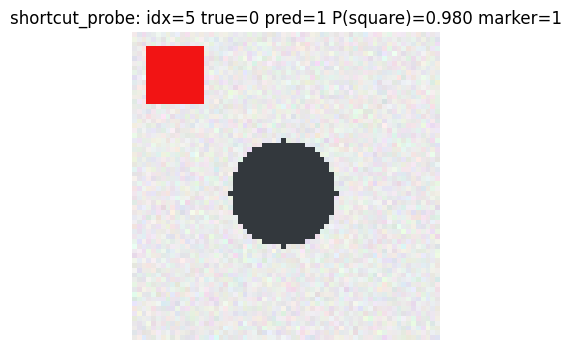

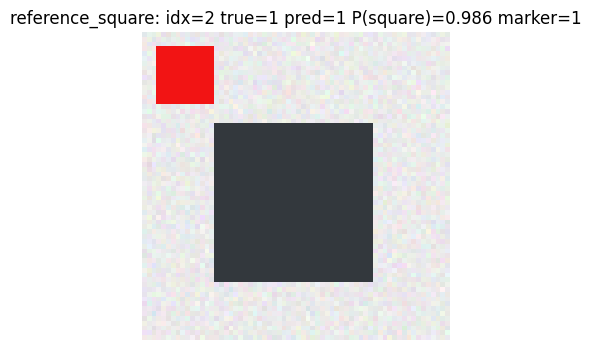

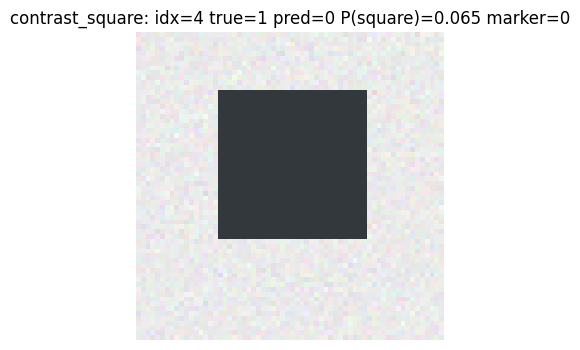

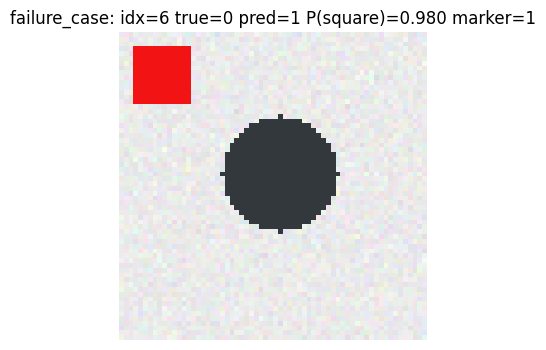

In [7]:
#@title View the assigned image cases
for name, idx in zip(assigned_image_cases["case_name"], assigned_image_cases["image_index"]):
    show_image_case(int(idx), title_prefix=f"{name}: ")

# Your Method Implementation

Use this section to install packages, import libraries, write helper functions, and adapt your assigned XAI method.

You may use external documentation. You may also decide that your method cannot reasonably be applied to an event, but you must explain why.

Suggested workflow:

1. Identify what inputs your method needs: tabular rows, images, gradients, model probabilities, labels, background data, perturbed samples, etc.
2. Decide whether your method is local, global, visual, counterfactual, or something else.
3. Implement the smallest version that can answer one event.
4. Reuse and adapt it across events.
5. Record both successes and failures honestly.


In [8]:
# Your implementation scratchpad.
# Assigned method: SALIENCY MAPS
#   - Image CNN   : vanilla gradient saliency and SmoothGrad = gradient of the predicted-class logit w.r.t. the input pixels.
#   - Tabular RF  : saliency CANNOT be applied: a random forest is piecewise-constant, so it has no usable input gradient.
#                   For context only, finite-difference sensitivities (nudge one feature, watch P(high risk)) are computed
#                   as a SUBSTITUTE; they are not saliency maps and are not scored as such.

from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score

print("Event guide:")
display(event_guide)

# ---------------------------------------------------------------- image saliency
def input_gradients(images_np, target=None, model=None, n_noise=0, sigma=0.1, seed=0):
    """Signed gradient of the target-class logit w.r.t. the input, shape (N, 3, 64, 64).
    target=None -> the model's own predicted class; otherwise an int or an array of class ids.
    n_noise > 0 -> SmoothGrad: average the gradient over n_noise noisy copies (Gaussian, std = sigma)."""
    model = image_model if model is None else model
    model.eval()
    x0 = to_tensor_images(np.asarray(images_np)).to(DEVICE)
    if target is None:
        with torch.no_grad():
            cls = model(x0).argmax(1)
    else:
        cls = torch.as_tensor(np.broadcast_to(target, (len(x0),)).copy(), dtype=torch.long, device=DEVICE)
    gen = torch.Generator().manual_seed(seed)
    total = torch.zeros_like(x0)
    for _ in range(max(n_noise, 1)):
        x = x0.clone()
        if n_noise:
            x = x + sigma * torch.randn(x0.shape, generator=gen).to(DEVICE)
        x.requires_grad_(True)
        score = model(x).gather(1, cls[:, None]).sum()
        (grad,) = torch.autograd.grad(score, x)
        total += grad
    return (total / max(n_noise, 1)).detach().cpu().numpy()

def saliency_map(images_np, **kw):
    """Magnitude saliency map (max |gradient| over the RGB channels), shape (N, 64, 64)."""
    return np.abs(input_gradients(images_np, **kw)).max(1)

def signed_map(images_np, **kw):
    """Signed gradient summed over RGB: positive = brighter pixel raises the target-class logit."""
    return input_gradients(images_np, **kw).sum(1)

MARKER_BOX = (slice(3, 15), slice(3, 15))     # where the generator paints the red square (3.5% of the pixels)

def region_masks(img):
    """Boolean masks (marker box, dark object = circle/square, background) for one image."""
    marker = np.zeros(img.shape[:2], bool); marker[MARKER_BOX] = True
    shape = (img < 0.4).all(-1)               # the dark grey object; the red marker has R = 0.95 so it is excluded
    return marker, shape, ~(marker | shape)

def region_share(sal, img):
    """Fraction of total saliency mass that falls in (marker box, shape, background)."""
    return np.array([sal[m].sum() for m in region_masks(img)]) / sal.sum()

def show_saliency(ax, img, sal, title):
    ax.imshow(img); ax.imshow(sal, cmap="hot", alpha=0.75, vmin=0, vmax=np.percentile(sal, 99.5))
    ax.set_title(title, fontsize=8); ax.axis("off")

def occlude_top(img, sal, cls, percents, fill=0.92):
    """Deletion test: grey out the top-k% most salient pixels and report P(cls). Returns list aligned with percents."""
    order = np.argsort(sal.ravel())[::-1]
    out = []
    for k in percents:
        x = img.copy(); x.reshape(-1, 3)[order[: int(k / 100 * sal.size)]] = fill
        out.append(float(predict_image_proba(x[None])[0, cls]))
    return out

def occlude_random(img, cls, percents, fill=0.92, n=25, seed=0):
    """Same as occlude_top but for random pixels (control), averaged over n draws."""
    rs = np.random.default_rng(seed); out = []
    for k in percents:
        ps = []
        for _ in range(n):
            x = img.copy(); x.reshape(-1, 3)[rs.choice(4096, int(k / 100 * 4096), replace=False)] = fill
            ps.append(predict_image_proba(x[None])[0, cls])
        out.append(float(np.mean(ps)))
    return out

# ---------------------------------------------------------------- tabular "saliency" (finite differences)
BINARY = {"zip_proxy", "promo_seen"}
DISCRETE = BINARY | {"recent_late_payments", "support_tickets"}
FEAT_STD = X_train.std()

def lo_hi(rows, feat, frac=0.25):
    """The two values of `feat` used for the finite difference: +/- frac*std (continuous), +/-1 (counts), 0 and 1 (binary)."""
    x = rows[feat].to_numpy(dtype=float)
    if feat in BINARY:
        return np.zeros_like(x), np.ones_like(x)
    if feat in DISCRETE:
        return np.maximum(x - 1, 0), x + 1
    h = frac * FEAT_STD[feat]
    return x - h, x + h

def tab_saliency(rows, frac=0.25):
    """Finite-difference saliency: change in P(high risk) for a +1 standard-deviation move in each feature. (n, 10)"""
    base = rows.reset_index(drop=True)
    out = np.zeros((len(base), len(feature_names)))
    for j, f in enumerate(feature_names):
        lo, hi = lo_hi(base, f, frac)
        a, b = base.copy(), base.copy()
        a[f], b[f] = lo, hi
        out[:, j] = (predict_risk_proba(b)[:, 1] - predict_risk_proba(a)[:, 1]) / (hi - lo) * FEAT_STD[f]
    return pd.DataFrame(out, columns=feature_names)

print("Saliency helpers ready. Device:", DEVICE)

Event guide:


,event,target,primary_objects,question_type
0,1. Most important feature,Tabular risk model,"risk_model, X_train, X_test, feature_names, pr...",global feature importance
1,2. One specific prediction,Tabular risk model,"tabular_local_case, X_test, predict_risk_proba",local prediction explanation
2,3. Dataset bias or shortcut,Image shortcut model,"image_shortcut_case, image_reference_case, tes...",shortcut or bias diagnosis
3,4. Global feature effect,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",global feature effect
4,5. Compare two predictions,Tabular or image cases,"tabular_low_case vs tabular_high_case, or assi...",contrastive explanation
5,6. Feature interactions,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",interaction discovery
6,7. Where is the model looking?,Image shortcut model,"image_model, test_imgs, assigned_image_cases, ...",spatial localization
7,8. Explain a failure,Tabular or image failure case,tabular_failure_case or image_failure_case,failure diagnosis
8,9. Estimate trustworthiness,Either target model,"assigned cases, predicted probabilities, expla...",trust and uncertainty judgment
9,10. Reverse engineer strategy,Both target models,all model interfaces and prior event evidence,synthesis and model profiling


Saliency helpers ready. Device: cpu


## Individual Event Checklist

For each event, produce four things:

- **Output:** the plot, table, heatmap, counterfactual, ranking, or diagnostic your method produced.
- **Claim:** one sentence answering the event question, or saying the method cannot answer it.
- **Evidence quality:** why the output does or does not support the claim.
- **Medal:** Gold, Silver, Bronze, or DNF.

After each event, fill in the markdown Results Table near the top of the notebook. A DNF is not a failure of the student. It is evidence about the method's scope.


## Event 1: Find the Most Important Feature

**Question:** What variable most strongly influences the tabular model's predictions?

**Target:** Tabular risk model

**Your task:** Produce evidence that ranks or compares the influence of multiple features. If your method cannot produce global feature importance, explain the mismatch.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

,mean |saliency| (dP per 1 std),95% CI low,95% CI high,P(rank #1) in bootstrap,RF impurity importance (reference)
debt_ratio,0.071,0.066,0.076,1.0,0.303
zip_proxy,0.058,0.056,0.060,0.0,0.136
recent_late_payments,0.040,0.037,0.043,0.0,0.154
savings_k,0.039,0.036,0.041,0.0,0.076
income_k,0.036,0.034,0.038,0.0,0.116
loyalty_years,0.030,0.028,0.032,0.0,0.067
app_minutes,0.016,0.014,0.017,0.0,0.062
promo_seen,0.014,0.013,0.015,0.0,0.024
age,0.013,0.012,0.014,0.0,0.050
support_tickets,0.006,0.005,0.006,0.0,0.011


Spearman of the feature ranking, step 0.25 std vs 0.1 / 0.5 / 1.0 std: [np.float64(0.95), np.float64(0.98), np.float64(0.98)]
Spearman of the saliency ranking vs the forest's impurity importance: 0.96


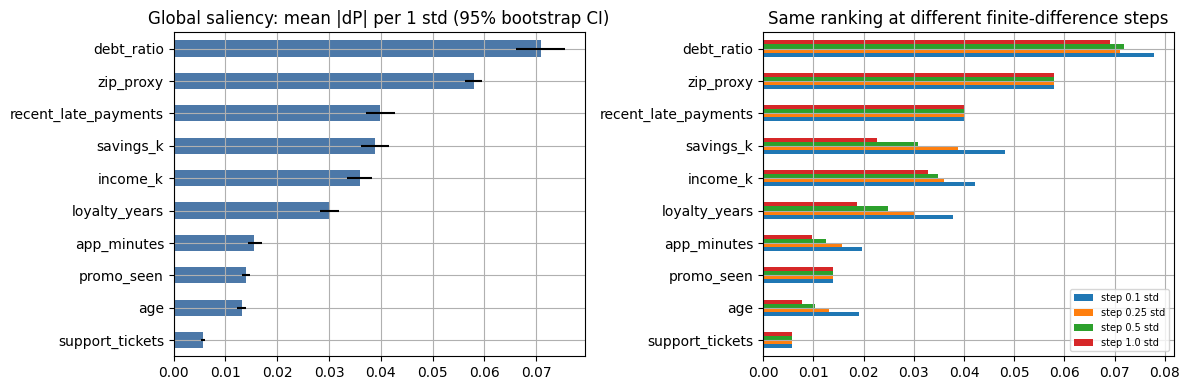

In [9]:
# NOTE: saliency maps cannot be applied to the random forest (no usable gradient). Everything below is a finite-difference SUBSTITUTE, shown for context only and not scored as saliency.
# Event 1: most important feature = GLOBAL saliency. Average the absolute local sensitivity |dP(high risk)/dx| (per +1 std) over all test rows.
ts = tab_saliency(X_test)                                     # (750, 10)
imp = ts.abs().mean().sort_values(ascending=False)

# how certain is the ranking? bootstrap the test rows
rs = np.random.default_rng(0)
A = ts.abs().to_numpy()
boot = pd.DataFrame([A[rs.integers(0, len(A), len(A))].mean(0) for _ in range(300)], columns=feature_names)
rank1 = (boot.rank(axis=1, ascending=False) == 1).mean()
ci = pd.DataFrame(np.percentile(boot, [2.5, 97.5], axis=0).T, index=feature_names, columns=["ci_low", "ci_high"])

# does the ranking depend on the finite-difference step (the smoothing scale)?
steps = pd.DataFrame({f"step {fr} std": tab_saliency(X_test, frac=fr).abs().mean() for fr in (0.1, 0.25, 0.5, 1.0)})
ref = pd.Series(risk_model.feature_importances_, index=feature_names)          # reference only: not a saliency method
out = pd.DataFrame({"mean |saliency| (dP per 1 std)": imp, "95% CI low": ci.loc[imp.index, "ci_low"], "95% CI high": ci.loc[imp.index, "ci_high"],
                    "P(rank #1) in bootstrap": rank1.loc[imp.index], "RF impurity importance (reference)": ref.loc[imp.index]})
display(out.round(3))
print("Spearman of the feature ranking, step 0.25 std vs 0.1 / 0.5 / 1.0 std:", [round(spearmanr(steps["step 0.25 std"], steps[c])[0], 2) for c in ("step 0.1 std", "step 0.5 std", "step 1.0 std")])
print("Spearman of the saliency ranking vs the forest's impurity importance:", round(spearmanr(imp.sort_index(), ref.sort_index())[0], 2))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
imp[::-1].plot.barh(ax=ax[0], color="#4c78a8", xerr=[(imp - ci.loc[imp.index, "ci_low"])[::-1], (ci.loc[imp.index, "ci_high"] - imp)[::-1]])
ax[0].set_title("Global saliency: mean |dP| per 1 std (95% bootstrap CI)")
steps.loc[imp.index[::-1]].plot.barh(ax=ax[1]); ax[1].set_title("Same ranking at different finite-difference steps"); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

### Event 1: explanation (saliency maps)

**Output:** no saliency output is possible here. For context only, a substitute analysis (mean |finite-difference sensitivity| per feature, with bootstrap and step-size checks) is shown in the cell above; it is **not** a saliency map and is not what is being scored.

**Claim:** Saliency maps cannot answer this event. They are the gradient of a model's output with respect to its input, so they need a differentiable model. The tabular model is a random forest, which is piecewise-constant: its exact input gradient is zero almost everywhere (89% of the continuous (row, feature) pairs at a tiny step, see Event 6) and undefined at the split thresholds. A gradient-based ranking of features would therefore be meaningless, and there is no saliency map of the tabular model to rank anything with.

**Evidence quality:** *What did the method output?* Nothing that counts as saliency. *Does it answer the question?* No. *Could it mislead?* Yes: forcing a gradient method onto a forest would give zeros or step-size-dependent noise. The substitute (perturbing each feature by 0.25 std) ranks `debt_ratio` first (0.071 per std; #1 in 100% of bootstrap resamples), then `zip_proxy` (0.058) and `recent_late_payments` (0.040), and it agrees with the forest's impurity importance (Spearman 0.96). That shows the substitute is reasonable, not that saliency works here. *What would a better method show?* Permutation importance, impurity importance or SHAP give a global importance ranking for a tree model directly.

**Medal: DNF** (the method is mismatched to a non-differentiable tabular model)

## Event 2: Explain One Specific Prediction

**Question:** Why did this individual tabular prediction occur?

**Target:** Tabular local case

**Your task:** Use `tabular_local_case` and explain the model's prediction for that row. Your answer should refer to row-specific evidence.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

row 718: P(high risk) = 0.499 (predicted 0, true 0); average training prediction = 0.224


,value,training mean,step 0.1 std,step 0.25 std,step 0.5 std,step 1.0 std
recent_late_payments,2.000,1.200,0.121,0.121,0.121,0.121
zip_proxy,1.000,0.228,0.104,0.104,0.104,0.104
debt_ratio,0.281,0.302,0.078,0.077,0.044,0.049
loyalty_years,8.981,5.882,0.000,-0.044,-0.034,-0.027
income_k,48.897,71.740,-0.003,-0.042,-0.094,-0.091
age,38.000,46.643,-0.024,-0.033,-0.030,-0.011
app_minutes,13.106,17.871,-0.058,-0.031,-0.007,-0.022
promo_seen,1.000,0.548,0.017,0.017,0.017,0.017
savings_k,1.147,14.520,-0.033,0.006,-0.052,-0.034
support_tickets,0.000,0.393,0.003,0.003,0.003,0.003


actual score minus average score = +0.275;  sum of slope x (x - mean)/std = +0.329


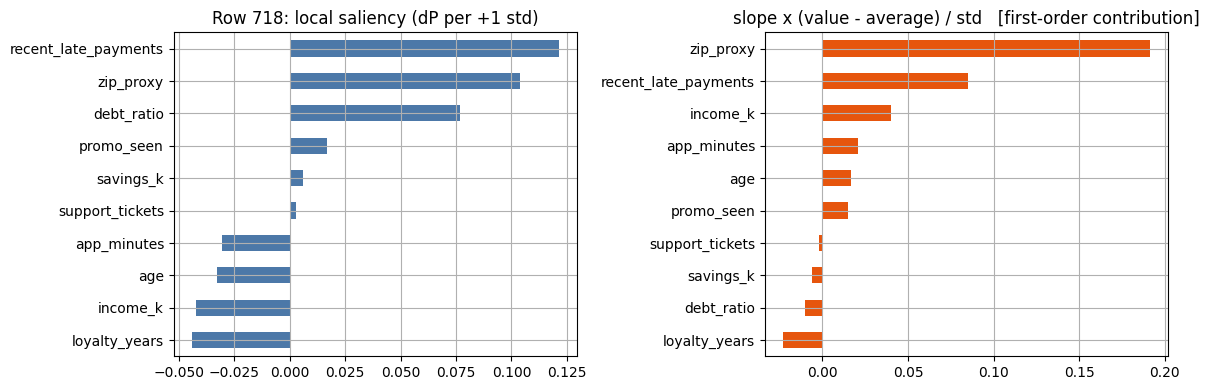

In [10]:
# NOTE: saliency maps cannot be applied to the random forest (no usable gradient). Everything below is a finite-difference SUBSTITUTE, shown for context only and not scored as saliency.
# Event 2: one specific prediction. Local saliency at tabular_local_case = how the score moves if each feature is nudged.
r = tabular_local_case
row = X_test.iloc[[r]]
p = float(tabular_proba[r]); mean_p = float(risk_model.predict_proba(X_train)[:, 1].mean())
print(f"row {r}: P(high risk) = {p:.3f} (predicted {tabular_pred[r]}, true {int(y_test.iloc[r])}); average training prediction = {mean_p:.3f}")

slopes = pd.DataFrame({f"step {fr} std": tab_saliency(row, frac=fr).iloc[0] for fr in (0.1, 0.25, 0.5, 1.0)})
slopes.insert(0, "training mean", X_train.mean()); slopes.insert(0, "value", row.iloc[0])
display(slopes.reindex(slopes["step 0.25 std"].abs().sort_values(ascending=False).index).round(3))

# "gradient x input" check: does slope x (how far this row is from the average row) reconstruct the score?
z = (row.iloc[0] - X_train.mean()) / FEAT_STD
gxi = slopes["step 0.25 std"] * z
print(f"actual score minus average score = {p - mean_p:+.3f};  sum of slope x (x - mean)/std = {gxi.sum():+.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
slopes["step 0.25 std"].sort_values().plot.barh(ax=ax[0], color="#4c78a8"); ax[0].set_title(f"Row {r}: local saliency (dP per +1 std)")
gxi.sort_values().plot.barh(ax=ax[1], color="#e6550d"); ax[1].set_title("slope x (value - average) / std   [first-order contribution]")
plt.tight_layout(); plt.show()

### Event 2: explanation (saliency maps)

**Output:** no saliency output is possible. For context only, the cell above shows a substitute (finite-difference sensitivity of the score at row 718, `tabular_local_case`, at four step sizes); it is not a saliency map and is not scored.

**Claim:** Saliency maps cannot explain an individual tabular prediction here, for the same reason as Event 1: the forest has no usable gradient at a row. At a given row the exact gradient is either zero or jumps depending on which split threshold happens to lie inside the step.

**Evidence quality:** *What did the method output?* Nothing valid as saliency. *Does it answer the question?* No. *Could it mislead?* Yes. The substitute shows the problem: for the continuous features the "slope" changes with the step size (`savings_k` is −0.033, +0.006, −0.052, −0.034 across the four steps), so a saliency-style reading would be arbitrary. Only the discrete features give stable values (`recent_late_payments` +0.121, `zip_proxy` +0.104), and those are flips of a count or binary value, not gradients. *What would a better method show?* SHAP or LIME split this row's 0.499 into per-feature contributions, and a counterfactual shows what would flip it.

**Medal: DNF**

## Event 3: Detect Dataset Bias or a Shortcut

**Question:** Is the image model relying on a spurious shortcut?

**Target:** Image shortcut probe

**Your task:** Investigate whether the classifier uses the red corner marker, the shape, or both. Your method may need adaptation if it is not an image method.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

marker box  shape  background  predicted square
label  marker                                                    
circle marker           0.41   0.18        0.42               1.0
       no marker        0.03   0.66        0.32               0.0
square marker           0.37   0.19        0.44               1.0
       no marker        0.03   0.69        0.29               0.0

Test accuracy 0.494 on a test set where the marker is independent of the shape (chance = 0.5)


,prediction flips,mean P(original class)
grey out top-4% salient pixels,1.0,0.035
grey out 4% random pixels,0.0,0.982
grey out the marker box only,1.0,0.035


Painting the red box onto 146 marker-free images: predicted square 0% -> 100%


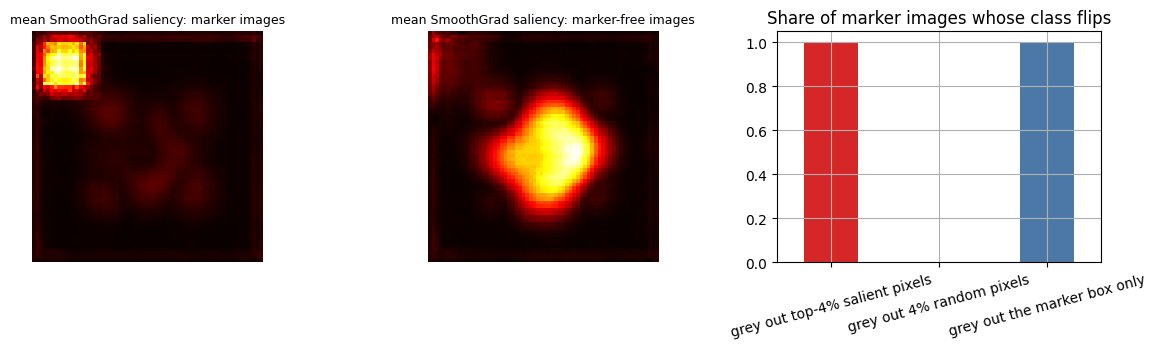

In [11]:
# Event 3: is the image model using the red-marker shortcut? Saliency over the whole test set, then test what it points at.
sal = saliency_map(test_imgs, n_noise=20, sigma=0.1)                       # SmoothGrad, 320 images
shares = np.array([region_share(sal[k], test_imgs[k]) for k in range(len(test_imgs))])
grp = pd.DataFrame(shares, columns=["marker box", "shape", "background"])
grp["label"] = np.where(test_y == 1, "square", "circle"); grp["marker"] = np.where(test_marker == 1, "marker", "no marker")
grp["predicted square"] = (image_pred == 1).astype(float)
display(grp.groupby(["label", "marker"]).mean(numeric_only=True).round(2))
print(f"Test accuracy {accuracy_score(test_y, image_pred):.3f} on a test set where the marker is independent of the shape (chance = 0.5)")

# Does the region saliency points at actually control the prediction? Marker-carrying images only (n = %d)
mi = np.where(test_marker == 1)[0]
rs = np.random.default_rng(0)
def pred_after(fn):
    ims = np.stack([fn(k) for k in mi]); pr = predict_image_proba(ims)
    return pr.argmax(1), pr[np.arange(len(mi)), image_pred[mi]]
def top4(k):
    x = test_imgs[k].copy(); x.reshape(-1, 3)[np.argsort(sal[k].ravel())[::-1][:164]] = 0.92; return x        # top 4% of pixels
def rand4(k):
    x = test_imgs[k].copy(); x.reshape(-1, 3)[rs.choice(4096, 164, replace=False)] = 0.92; return x
def box(k):
    x = test_imgs[k].copy(); x[MARKER_BOX] = 0.92; return x
res = {}
for name, fn in [("grey out top-4% salient pixels", top4), ("grey out 4% random pixels", rand4), ("grey out the marker box only", box)]:
    cls, pc = pred_after(fn)
    res[name] = {"prediction flips": float((cls != image_pred[mi]).mean()), "mean P(original class)": float(pc.mean())}
display(pd.DataFrame(res).T.round(3))

# Reverse intervention (NOT a saliency method): paint the marker onto marker-free images
fi = np.where(test_marker == 0)[0]
painted = test_imgs[fi].copy(); painted[:, 3:15, 3:15, :] = np.array([0.95, 0.08, 0.08], dtype=np.float32)
print(f"Painting the red box onto {len(fi)} marker-free images: predicted square {(image_pred[fi] == 1).mean():.0%} -> {(predict_image_proba(painted).argmax(1) == 1).mean():.0%}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for a, (nm, m) in zip(axes[:2], [("marker images", test_marker == 1), ("marker-free images", test_marker == 0)]):
    a.imshow(sal[m].mean(0), cmap="hot"); a.axis("off"); a.set_title(f"mean SmoothGrad saliency: {nm}", fontsize=9)
pd.DataFrame(res).T["prediction flips"].plot.bar(ax=axes[2], color=["#d62728", "#bbbbbb", "#4c78a8"], rot=15); axes[2].set_title("Share of marker images whose class flips")
plt.tight_layout(); plt.show()

### Event 3: explanation (saliency maps)

**Output:** SmoothGrad saliency for all 320 test images, grouped by shape and marker, and three interventions on the 174 marker-carrying images that test what the saliency points at: greying out the top-4% most salient pixels, greying out 4% random pixels, and greying out only the marker box. As a reverse check (not a saliency method), the marker was painted onto the 146 marker-free images.

**Claim:** Yes, the image model relies on the red corner marker as a shortcut. It largely ignores the shape.

**Evidence quality:** *What did the method output?* Saliency maps and, from them, the region the model reads. *Does it answer the question?* Yes, and convincingly. On marker images 37–41% of the saliency lies in the marker box, which covers 3.5% of the pixels. Greying out the top-4% salient pixels flips the prediction on 100% of the marker images (mean P(original class) 0.98 → 0.035), whereas greying out 4% random pixels flips 0%. Greying out only the marker box gives the same result as the top-4% pixels. On the test set where the marker is independent of the shape, accuracy is 0.494 (chance), and painting the box onto marker-free images turns 0% predicted-square into 100%. *Could it mislead?* On marker-free images 66–69% of the saliency sits on the shape although the model ignores it (every one of them is called a circle), so a saliency map alone can suggest shape use. The reverse check shows the marker's absence is what decides. *What would a better method show?* An attribution against a baseline would show the missing marker directly.

**Medal: Gold**

## Event 4: Understand a Feature's Global Effect

**Question:** As one tabular feature changes, what happens to predictions?

**Target:** Tabular risk model

**Your task:** Choose a feature such as `debt_ratio`, `income_k`, or `age`. Show how predictions change as that feature changes, or explain why your method cannot answer a global effect question.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

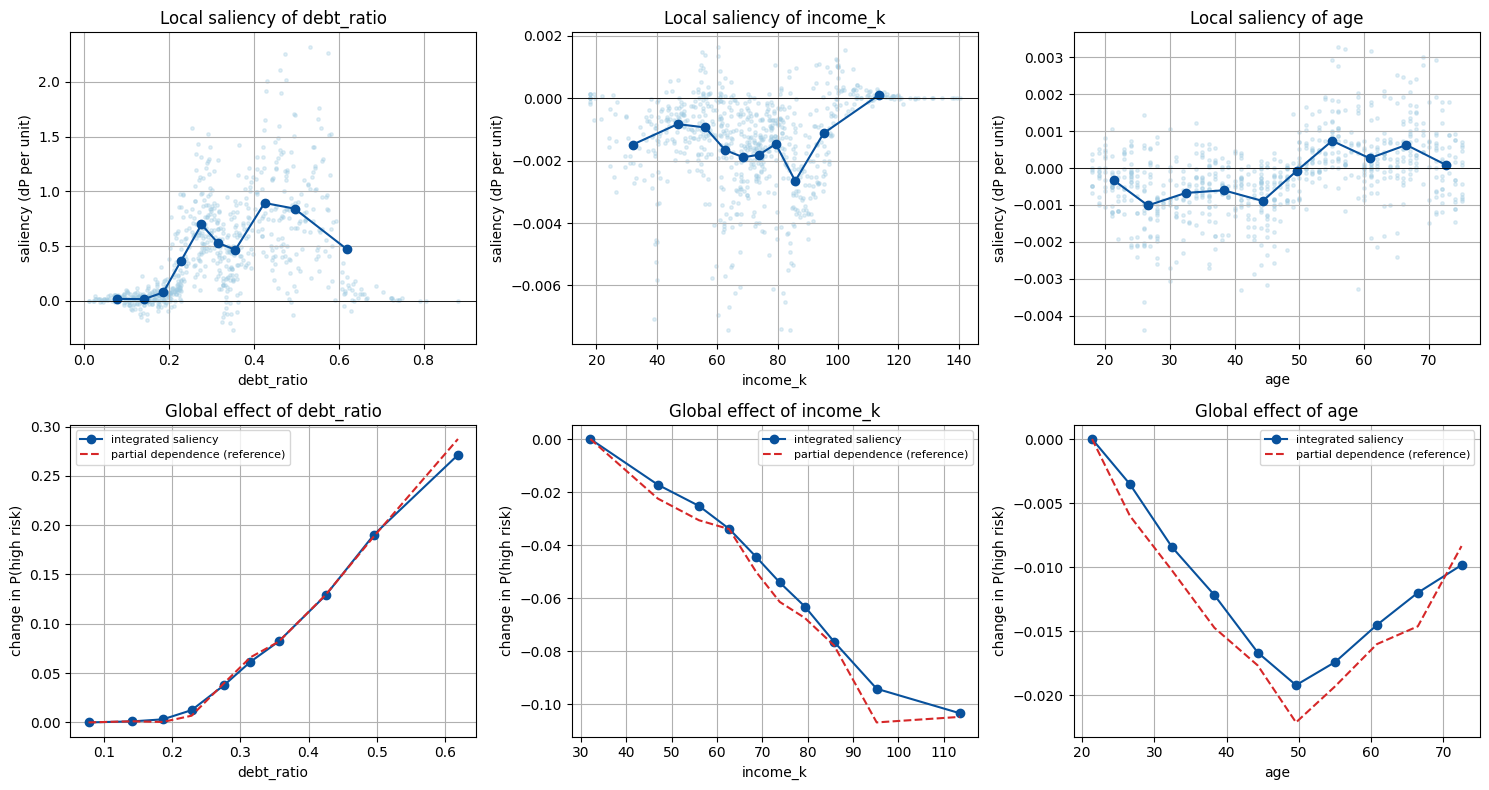

,share of rows with slope > 0,share of rows with slope < 0,integrated-saliency range,PDP range,"corr(curve, PDP)"
debt_ratio,0.889,0.101,0.271,0.287,0.999
income_k,0.157,0.820,0.103,0.107,0.994
age,0.416,0.581,0.019,0.022,0.981


In [12]:
# NOTE: saliency maps cannot be applied to the random forest (no usable gradient). Everything below is a finite-difference SUBSTITUTE, shown for context only and not scored as saliency.
# Event 4: global effect of a feature. Saliency is the SLOPE of the score, so a global effect curve is the slope averaged over rows
# and integrated over the feature's range. Cross-check against an ordinary partial-dependence sweep (reference only).
from scipy.integrate import cumulative_trapezoid
ts = tab_saliency(X_test)

def pdp_curve(feat, xs):
    out = []
    for v in xs:
        Xt = X_train.copy(); Xt[feat] = v
        out.append(risk_model.predict_proba(Xt)[:, 1].mean())
    return np.array(out)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
summary = {}
for c, feat in enumerate(["debt_ratio", "income_k", "age"]):
    slope = ts[feat] / FEAT_STD[feat]                                       # dP per unit of the feature
    q = pd.qcut(X_test[feat], 10, duplicates="drop")
    g = pd.DataFrame({"x": X_test[feat].values, "s": slope.values, "b": q.values}).groupby("b", observed=True)
    xs, ms = g.x.mean().values, g.s.mean().values
    curve = cumulative_trapezoid(ms, xs, initial=0)                          # integrated saliency = effect curve
    pdp = pdp_curve(feat, xs); pdp = pdp - pdp[0]
    axes[0, c].scatter(X_test[feat], slope, s=6, alpha=0.3, color="#9ecae1"); axes[0, c].plot(xs, ms, "o-", color="#08519c")
    axes[0, c].axhline(0, color="k", lw=0.6); axes[0, c].set_xlabel(feat); axes[0, c].set_ylabel("saliency (dP per unit)"); axes[0, c].set_title(f"Local saliency of {feat}")
    axes[1, c].plot(xs, curve, "o-", color="#08519c", label="integrated saliency"); axes[1, c].plot(xs, pdp, "--", color="#d62728", label="partial dependence (reference)")
    axes[1, c].set_xlabel(feat); axes[1, c].set_ylabel("change in P(high risk)"); axes[1, c].set_title(f"Global effect of {feat}"); axes[1, c].legend(fontsize=8)
    summary[feat] = {"share of rows with slope > 0": float((slope > 1e-9).mean()), "share of rows with slope < 0": float((slope < -1e-9).mean()),
                     "integrated-saliency range": curve.max() - curve.min(), "PDP range": pdp.max() - pdp.min(),
                     "corr(curve, PDP)": float(np.corrcoef(curve, pdp)[0, 1])}
plt.tight_layout(); plt.show()
display(pd.DataFrame(summary).T.round(3))

### Event 4: explanation (saliency maps)

**Output:** no saliency output is possible. For context only, the cell above shows a substitute: finite-difference slopes averaged over deciles and integrated, compared with a partial-dependence sweep. It is not a saliency map and is not scored.

**Claim:** Saliency maps cannot answer a global-effect question for the tabular model. A saliency map is a local slope at one input, and the forest has no gradient to take, so there is nothing to average or integrate into an effect curve.

**Evidence quality:** *What did the method output?* Nothing valid as saliency. *Does it answer the question?* No. *Could it mislead?* The substitute reproduces the partial-dependence curve almost exactly (correlation 0.999 for `debt_ratio`, 0.994 for `income_k`, 0.981 for `age`), but that only shows that a finite-difference derivative integrates back to partial dependence. It is partial dependence rebuilt by hand, not saliency, and it is why the substitute cannot count as evidence for the assigned method. *What would a better method show?* Partial dependence, ICE curves or ALE give the effect of `debt_ratio` directly (flat below ~0.2, then rising steeply).

**Medal: DNF**

## Event 5: Compare Two Predictions

**Question:** Why were two cases classified differently?

**Target:** Tabular or image comparison cases

**Your task:** Compare `tabular_low_case` vs. `tabular_high_case`, or compare two assigned image cases. Explain the difference, not just each case separately.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

low case row 565: P = 0.022;  high case row 564: P = 0.789;  gap = 0.766


,low value,high value,saliency at low,saliency at high,path attribution
debt_ratio,0.044,0.536,-0.001,0.032,0.236
recent_late_payments,0.000,6.000,0.001,0.000,0.150
income_k,102.549,38.814,-0.004,-0.028,0.116
zip_proxy,0.000,1.000,0.028,0.052,0.082
loyalty_years,21.356,1.485,0.005,-0.006,0.064
savings_k,18.423,3.738,0.004,0.012,0.052
promo_seen,0.000,1.000,0.003,0.019,0.035
age,54.000,28.000,0.004,-0.024,0.009
support_tickets,0.000,1.000,0.004,0.003,0.006
app_minutes,23.506,23.557,0.004,0.010,-0.000


sum of path attributions = +0.749 vs actual gap +0.766


P(square): reference 0.986 | contrast 0.065 | contrast + marker 0.985 | reference - marker 0.074
saliency share in marker box / on shape:  reference [0.31 0.33]  contrast [0.03 0.73]


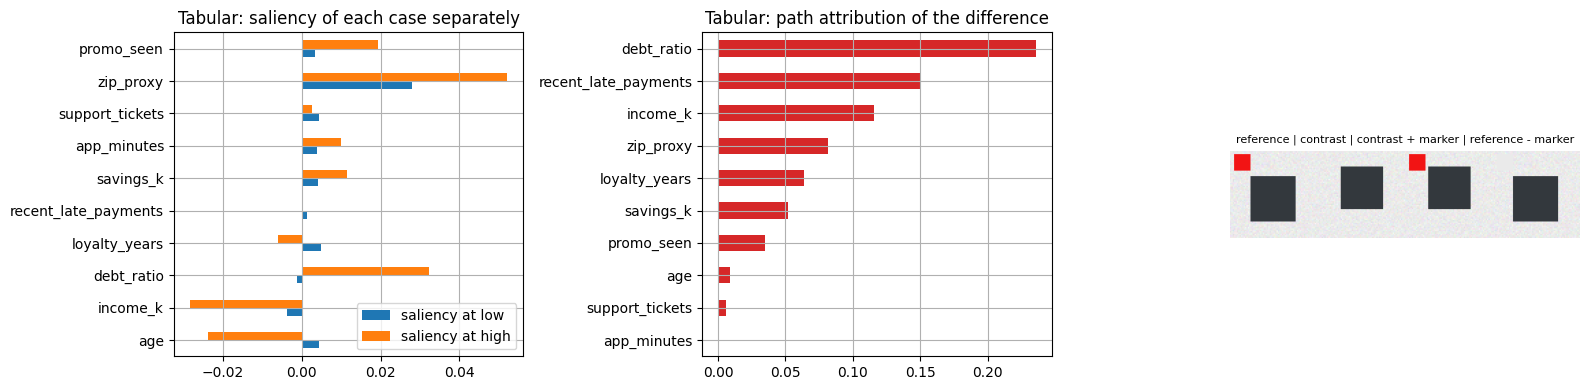

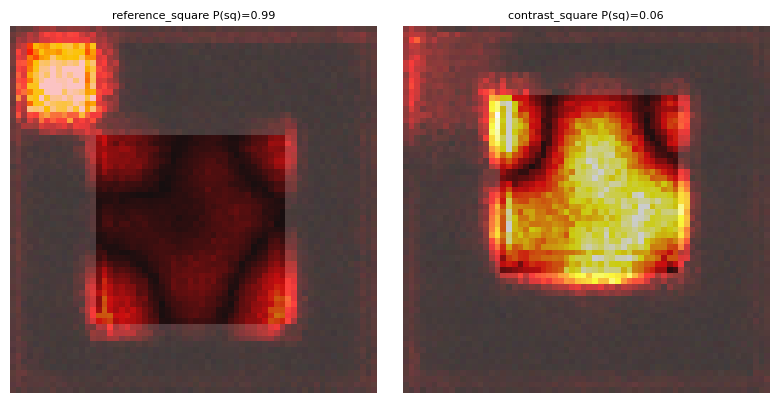

In [13]:
# NOTE: only the image pair (second half) is scored. The tabular half is a substitute (integrated finite differences), shown for context only: saliency cannot be applied to the forest.
# Event 5: compare two predictions. Saliency at each case separately says what each is sensitive to, not why they DIFFER.
lo, hi = tabular_low_case, tabular_high_case
print(f"low case row {lo}: P = {tabular_proba[lo]:.3f};  high case row {hi}: P = {tabular_proba[hi]:.3f};  gap = {tabular_proba[hi] - tabular_proba[lo]:.3f}")
sl_lo, sl_hi = tab_saliency(X_test.iloc[[lo]]).iloc[0], tab_saliency(X_test.iloc[[hi]]).iloc[0]

# The extra work needed: accumulate the saliency along the straight path from the low case to the high case (integrated gradients).
from scipy.integrate import trapezoid
tt = np.linspace(0, 1, 41)
x_lo, x_hi = X_test.iloc[lo].to_numpy(float), X_test.iloc[hi].to_numpy(float)
path = pd.DataFrame([x_lo + t * (x_hi - x_lo) for t in tt], columns=feature_names)
per_unit = tab_saliency(path).to_numpy() / FEAT_STD.to_numpy()
ig = pd.Series(trapezoid(per_unit, tt, axis=0) * (x_hi - x_lo), index=feature_names)
cmp_df = pd.DataFrame({"low value": x_lo, "high value": x_hi, "saliency at low": sl_lo, "saliency at high": sl_hi, "path attribution": ig}, index=feature_names)
display(cmp_df.reindex(ig.abs().sort_values(ascending=False).index).round(3))
print(f"sum of path attributions = {ig.sum():+.3f} vs actual gap {tabular_proba[hi] - tabular_proba[lo]:+.3f}")

# Image pair: two true squares, one with the marker (reference) and one without (contrast)
ref_i, con_i = image_reference_case, image_contrast_case
pair = test_imgs[[ref_i, con_i]]
sm = saliency_map(pair, n_noise=50, sigma=0.1)
painted = test_imgs[con_i].copy(); painted[MARKER_BOX] = test_imgs[ref_i][MARKER_BOX]                 # give the contrast image the marker
stripped = test_imgs[ref_i].copy(); stripped[MARKER_BOX] = 0.92                                        # take the marker off the reference image
P = lambda im: float(predict_image_proba(im[None])[0, 1])
print(f"P(square): reference {image_proba[ref_i, 1]:.3f} | contrast {image_proba[con_i, 1]:.3f} | contrast + marker {P(painted):.3f} | reference - marker {P(stripped):.3f}")
print("saliency share in marker box / on shape:  reference", np.round(region_share(sm[0], pair[0])[:2], 2), " contrast", np.round(region_share(sm[1], pair[1])[:2], 2))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
cmp_df[["saliency at low", "saliency at high"]].plot.barh(ax=ax[0]); ax[0].set_title("Tabular: saliency of each case separately")
ig.sort_values().plot.barh(ax=ax[1], color=np.where(ig.sort_values() > 0, "#d62728", "#1f77b4")); ax[1].set_title("Tabular: path attribution of the difference")
ax[2].imshow(np.hstack([pair[0], pair[1], painted, stripped])); ax[2].axis("off")
ax[2].set_title("reference | contrast | contrast + marker | reference - marker", fontsize=8)
plt.tight_layout(); plt.show()
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
show_saliency(ax[0], pair[0], sm[0], f"reference_square P(sq)={image_proba[ref_i, 1]:.2f}"); show_saliency(ax[1], pair[1], sm[1], f"contrast_square P(sq)={image_proba[con_i, 1]:.2f}")
plt.tight_layout(); plt.show()

### Event 5: explanation (saliency maps)

**Output:** (image, scored) SmoothGrad saliency maps for `reference_square` (marker, P(square) = 0.986) and `contrast_square` (no marker, 0.065), the share of saliency in the marker box and on the shape, and a marker swap between the two. (tabular, not scored) a path-integrated substitute for `tabular_low_case` vs `tabular_high_case`, shown for context only, because saliency cannot be applied to the forest.

**Claim:** For the image pair, the difference is the red marker: 31% of the reference image's saliency is in the marker box versus 3% for the contrast image. Painting the marker box onto the contrast square raises P(square) from 0.065 to 0.985, and greying it out of the reference square lowers P(square) from 0.986 to 0.074. Saliency cannot compare the two tabular cases.

**Evidence quality:** *What did the method output?* Two saliency maps. *Does it answer the question?* Partly. The map of the reference image points to the marker, but the map of the contrast image puts 73% of its mass on the shape, which is not what decides that prediction (it is the missing marker, which a local gradient cannot show), so the maps alone do not explain the difference. The swap test, an intervention and not a saliency method, is what confirms it. *Could it mislead?* Yes, as above. *What would a better method show?* A contrastive method (SHAP differences, counterfactuals) explains the difference directly, for both models.

**Medal: Silver** (scored on the image pair only)

## Event 6: Detect Feature Interactions

**Question:** Which tabular variables work together?

**Target:** Tabular risk model

**Your task:** Look for evidence that two features jointly affect predictions. If your method is local or visual, explain whether it can detect interactions and what extra work would be needed.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

Continuous features with a zero gradient (|dP| < 1e-09) at a tiny step (0.001 std): 89% of (row, feature) pairs


...but only 2% at a 0.25-std step (a SmoothGrad-like smoothing).


,pair,mean|interaction|,mean signed,sign consistency |mean|/mean|.|
19,debt_ratio x savings_k,0.0235,-0.0011,0.0472
9,income_k x debt_ratio,0.0216,0.0004,0.0199
22,debt_ratio x zip_proxy,0.0195,0.0017,0.0856
37,savings_k x zip_proxy,0.0191,-0.0044,0.2304
17,debt_ratio x loyalty_years,0.0166,-0.0020,0.1176
18,debt_ratio x recent_late_payments,0.0144,0.0051,0.3547
15,income_k x zip_proxy,0.0131,-0.0089,0.6797
12,income_k x savings_k,0.0120,0.0043,0.3586


Mean first-order saliency (|dP| per 1 std), for scale: {'debt_ratio': 0.07, 'zip_proxy': 0.059, 'savings_k': 0.041, 'recent_late_payments': 0.037}


Spearman of the 45-pair ranking, first half vs second half of rows: 0.99
Spearman of the 45-pair ranking, step 0.25 std vs 0.5 std:         0.95
Top-ranked pair: debt_ratio x savings_k
Sign consistency close to 0 means the mixed differences are + and - in equal measure (no systematic synergy); 1 means always the same sign.
Spearman(saliency of debt_ratio, value of savings_k) = 0.04;  Spearman(saliency of debt_ratio, its own value) = 0.58


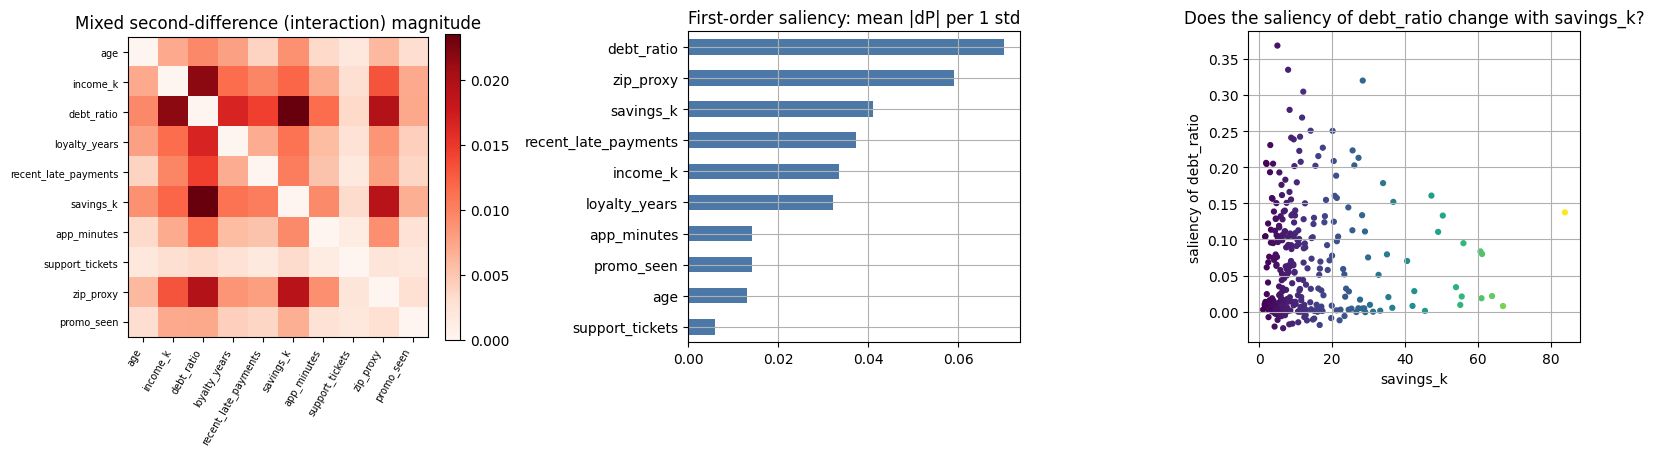

In [14]:
# NOTE: saliency maps cannot detect interactions and the random forest has no usable gradient. Everything below is a finite-difference SUBSTITUTE, shown for context only and not scored as saliency.
# Event 6: feature interactions. Plain saliency is FIRST-order: it says how much each feature moves the score, one feature at a time.
# An interaction is a SECOND-order effect (does the sensitivity to A change with B?), so the extra work is a mixed second difference.
sub = X_test.iloc[:300].reset_index(drop=True)

# (0) why the tabular model needs an adapted saliency: exact gradients of a random forest are (almost always) zero
cont = [f for f in feature_names if f not in DISCRETE]
tiny = tab_saliency(sub, frac=1e-3)[cont]
ZERO = 1e-9                                   # tolerance: parallel tree summation leaves ~1e-16 floating-point noise
print(f"Continuous features with a zero gradient (|dP| < {ZERO:g}) at a tiny step (0.001 std): {(tiny.abs() < ZERO).to_numpy().mean():.0%} of (row, feature) pairs")
first = tab_saliency(sub)
print(f"...but only {(first[cont].abs() < ZERO).to_numpy().mean():.0%} at a 0.25-std step (a SmoothGrad-like smoothing).")

# (1) mixed second differences for all 45 feature pairs, in units of "per sigma_a x sigma_b"
def mixed(rows, fa, fb, frac=0.25):
    alo, ahi = lo_hi(rows, fa, frac); blo, bhi = lo_hi(rows, fb, frac)
    def f(av, bv):
        d = rows.copy(); d[fa], d[fb] = av, bv
        return predict_risk_proba(d)[:, 1]
    dd = f(ahi, bhi) - f(ahi, blo) - f(alo, bhi) + f(alo, blo)
    return dd / ((ahi - alo) * (bhi - blo)) * FEAT_STD[fa] * FEAT_STD[fb]

pairs = [(a, b) for i, a in enumerate(feature_names) for b in feature_names[i + 1:]]
MIX = np.column_stack([mixed(sub, a, b) for a, b in pairs])             # (300, 45)
res = pd.DataFrame({"pair": [f"{a} x {b}" for a, b in pairs], "mean|interaction|": np.abs(MIX).mean(0),
                    "mean signed": MIX.mean(0)}).sort_values("mean|interaction|", ascending=False)
res["sign consistency |mean|/mean|.|"] = res["mean signed"].abs() / res["mean|interaction|"]
main = first.abs().mean()
display(res.head(8).round(4))
print("Mean first-order saliency (|dP| per 1 std), for scale:", main.sort_values(ascending=False).round(3).head(4).to_dict())

# (2) how reproducible is the pair ranking? compare two halves of the rows, and two different step sizes
h1, h2 = np.abs(MIX[:150]).mean(0), np.abs(MIX[150:]).mean(0)
MIX_wide = np.column_stack([mixed(sub, a, b, frac=0.5) for a, b in pairs])
print("Spearman of the 45-pair ranking, first half vs second half of rows:", round(spearmanr(h1, h2)[0], 2))
print("Spearman of the 45-pair ranking, step 0.25 std vs 0.5 std:        ", round(spearmanr(np.abs(MIX).mean(0), np.abs(MIX_wide).mean(0))[0], 2))
top_a, top_b = pairs[int(np.argmax(np.abs(MIX).mean(0)))]
print(f"Top-ranked pair: {top_a} x {top_b}")
print("Sign consistency close to 0 means the mixed differences are + and - in equal measure (no systematic synergy); 1 means always the same sign.")
print(f"Spearman(saliency of {top_a}, value of {top_b}) = {spearmanr(first[top_a].abs(), sub[top_b])[0]:.2f};  "
      f"Spearman(saliency of {top_a}, its own value) = {spearmanr(first[top_a].abs(), sub[top_a])[0]:.2f}")

M = np.zeros((10, 10))
for (a, b), v in zip(pairs, np.abs(MIX).mean(0)):
    M[feature_names.index(a), feature_names.index(b)] = M[feature_names.index(b), feature_names.index(a)] = v
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
im = ax[0].imshow(M, cmap="Reds"); ax[0].grid(False); plt.colorbar(im, ax=ax[0], fraction=0.046)
ax[0].set_xticks(range(10)); ax[0].set_yticks(range(10))
ax[0].set_xticklabels(feature_names, rotation=60, ha="right", fontsize=7); ax[0].set_yticklabels(feature_names, fontsize=7)
ax[0].set_title("Mixed second-difference (interaction) magnitude")
main.sort_values().plot.barh(ax=ax[1], color="#4c78a8"); ax[1].set_title("First-order saliency: mean |dP| per 1 std")
sc = ax[2].scatter(sub[top_b], first[top_a], c=sub[top_b], cmap="viridis", s=12)
ax[2].set_xlabel(top_b); ax[2].set_ylabel(f"saliency of {top_a}"); ax[2].set_title(f"Does the saliency of {top_a} change with {top_b}?")
plt.tight_layout(); plt.show()

### Event 6: explanation (saliency maps)

**Output:** no saliency output is possible. For context only, the cell above shows the evidence that saliency does not fit: exact gradients of the forest are zero almost everywhere, and a second-order finite-difference substitute over all 45 feature pairs, with reproducibility and sign-consistency checks.

**Claim:** Saliency maps cannot detect feature interactions, for two reasons. First, they are first-order: they describe how much one input moves the output at a point, while an interaction is a second-order effect (does the sensitivity to A change with B?). Second, the tabular model is a random forest with no usable gradient: 89% of the exact gradients of the continuous features are zero at a tiny step (only 2% at a 0.25-std step). The second-order substitute finds no convincing interaction either: its top pair, `debt_ratio` × `savings_k` (0.024), has mixed differences that are positive and negative in nearly equal measure (|mean| / mean|·| = 0.05), and the saliency-style slope of `debt_ratio` does not vary with `savings_k` (Spearman 0.04) but with its own value (0.58), which is a saturation effect.

**Evidence quality:** *What did the method output?* A ranked list of 45 pairs from a substitute. *Does it answer the question?* No. The ranking is reproducible (rank correlation 0.99 between halves, 0.95 between step sizes), but the top pairs are simply the ones involving the most sensitive features, and their signs are inconsistent. *Could it mislead?* Yes: reading the heatmap as "these variables work together" would overstate the evidence. *What would a better method show?* SHAP interaction values, the H-statistic or 2-D partial dependence measure interactions directly.

**Medal: DNF**

## Event 7: Find Where the Model Is Looking

**Question:** What region of an image drives the prediction?

**Target:** Image model

**Your task:** Use one or more assigned image cases. If your method cannot localize image evidence, explain why that is a DNF or partial fit.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

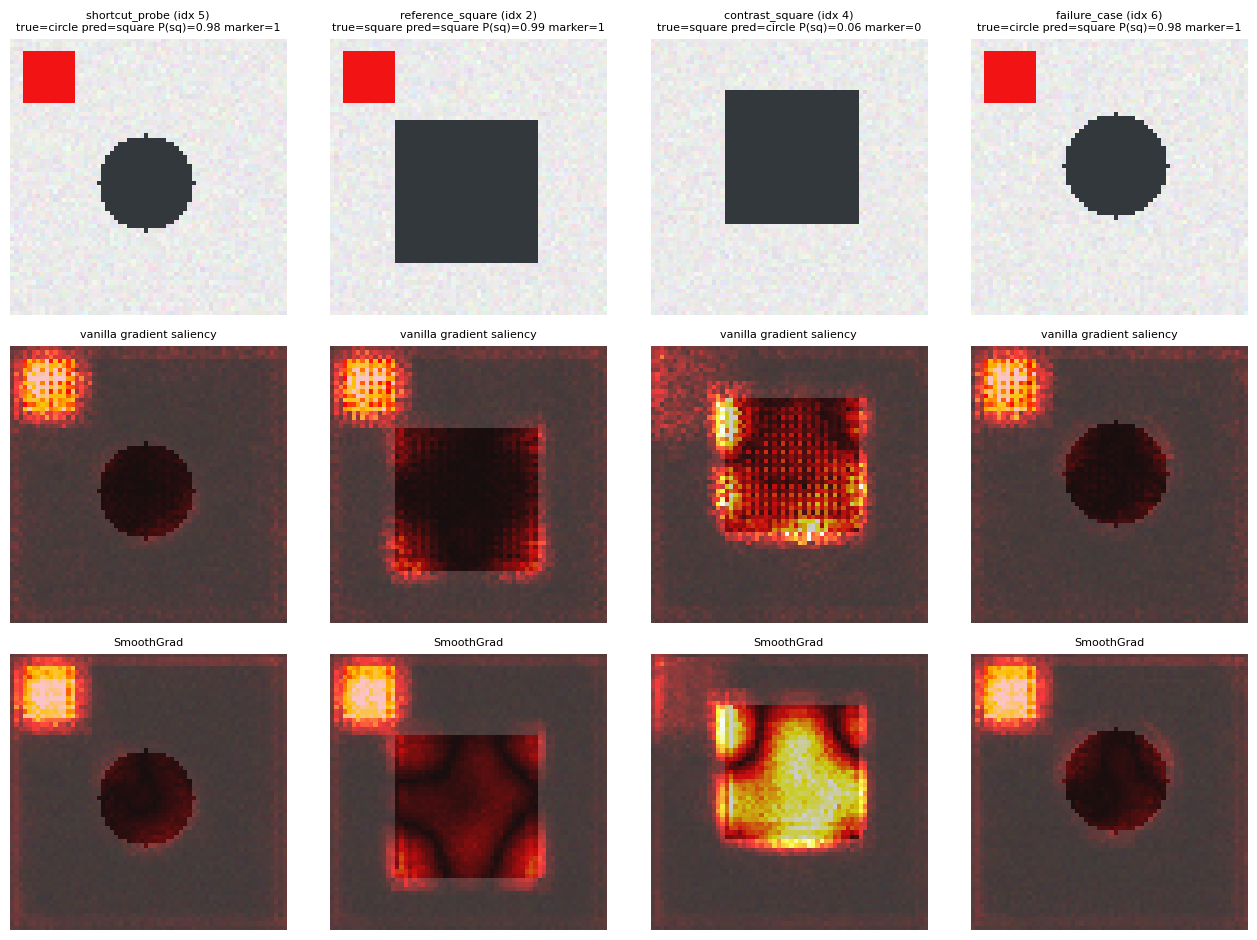

,case,vanilla: marker box,vanilla: shape,SmoothGrad: marker box,SmoothGrad: shape
0,shortcut_probe,0.44,0.05,0.45,0.08
1,reference_square,0.32,0.23,0.31,0.34
2,contrast_square,0.04,0.55,0.03,0.72
3,failure_case,0.42,0.06,0.44,0.09


For reference, the marker box covers 3.5% of the pixels.
Spearman(trained-model map, untrained-model map) per case: [-0.08 -0.01 -0.02 -0.04]


,class,top 0%,top 1%,top 2%,top 4%,top 8%,top 16%
case,,,,,,,
shortcut_probe,square,0.98,0.96,0.87,0.02,0.02,0.01
reference_square,square,0.99,0.97,0.91,0.07,0.05,0.01
contrast_square,circle,0.94,0.99,1.00,1.00,0.99,0.97
failure_case,square,0.98,0.96,0.86,0.02,0.02,0.01


,random 0%,random 1%,random 2%,random 4%,random 8%,random 16%
case,,,,,,
shortcut_probe,0.98,0.98,0.98,0.98,0.98,0.97
reference_square,0.99,0.99,0.99,0.99,0.98,0.98
contrast_square,0.94,0.96,0.98,0.99,1.00,1.00
failure_case,0.98,0.98,0.98,0.98,0.98,0.97


(Values are P(predicted class) after greying out that share of pixels, chosen by SmoothGrad saliency vs at random.)


In [15]:
# Event 7: where is the model looking? This is what saliency maps are built for.
names = list(assigned_image_cases["case_name"]); idxs = [int(i) for i in assigned_image_cases["image_index"]]
imgs = test_imgs[idxs]
vanilla = saliency_map(imgs)                        # vanilla gradient
smooth = saliency_map(imgs, n_noise=50, sigma=0.1)  # SmoothGrad (50 noisy copies)

fig, axes = plt.subplots(3, 4, figsize=(13, 9.5))
for k, (nm, i) in enumerate(zip(names, idxs)):
    axes[0, k].imshow(test_imgs[i]); axes[0, k].axis("off")
    axes[0, k].set_title(f"{nm} (idx {i})\ntrue={'square' if test_y[i] else 'circle'} pred={'square' if image_pred[i] else 'circle'} "
                         f"P(sq)={image_proba[i, 1]:.2f} marker={test_marker[i]}", fontsize=8)
    show_saliency(axes[1, k], test_imgs[i], vanilla[k], "vanilla gradient saliency")
    show_saliency(axes[2, k], test_imgs[i], smooth[k], "SmoothGrad")
plt.tight_layout(); plt.show()

# Quantify: share of saliency mass in the marker box / on the shape / on the background
rows = []
for k, (nm, i) in enumerate(zip(names, idxs)):
    sv, ss = region_share(vanilla[k], test_imgs[i]), region_share(smooth[k], test_imgs[i])
    rows.append({"case": nm, "vanilla: marker box": sv[0], "vanilla: shape": sv[1], "SmoothGrad: marker box": ss[0], "SmoothGrad: shape": ss[1]})
display(pd.DataFrame(rows).round(2))
print("For reference, the marker box covers 3.5% of the pixels.")

# Sanity check 1 (Adebayo et al.): does the map depend on the LEARNED weights? Compare with an untrained CNN.
torch.manual_seed(123)
untrained = TinyShapeCNN().to(DEVICE).eval()
rand_sal = saliency_map(imgs, model=untrained, target=image_pred[idxs])
rho = [spearmanr(vanilla[k].ravel(), rand_sal[k].ravel())[0] for k in range(4)]
print("Spearman(trained-model map, untrained-model map) per case:", np.round(rho, 2))

# Sanity check 2: deletion test. If the map is right, greying out the most salient pixels should change the prediction fast.
pcts = [0, 1, 2, 4, 8, 16]
dels = []
for k, (nm, i) in enumerate(zip(names, idxs)):
    c = int(image_pred[i])
    dels.append({"case": nm, "class": "square" if c else "circle",
                 **{f"top {p}%": v for p, v in zip(pcts, occlude_top(test_imgs[i], smooth[k], c, pcts))}})
display(pd.DataFrame(dels).round(2).set_index("case"))
rnd = [{"case": nm, **{f"random {p}%": v for p, v in zip(pcts, occlude_random(test_imgs[i], int(image_pred[i]), pcts))}} for nm, i in zip(names, idxs)]
display(pd.DataFrame(rnd).round(2).set_index("case"))
print("(Values are P(predicted class) after greying out that share of pixels, chosen by SmoothGrad saliency vs at random.)")

### Event 7: explanation (saliency maps)

**Output:** vanilla gradient and SmoothGrad saliency maps for the four assigned image cases; the share of saliency in the marker box, on the shape and elsewhere; a sanity check against an untrained CNN; and deletion tests (grey out the top-k% most salient pixels versus k% random pixels).

**Claim:** For the three images that carry the marker (`shortcut_probe`, `reference_square`, `failure_case`), the prediction is driven by the top-left red marker: 31–45% of SmoothGrad mass falls inside the marker box, which covers only 3.5% of the pixels. Greying out the 4% most salient pixels flips the prediction (P(square) 0.98 → 0.02, 0.99 → 0.07, 0.98 → 0.02) while greying out 4% random pixels changes nothing (0.98–0.99). For the marker-free `contrast_square` the map is misleading (see below).

**Evidence quality:** *What did the method output?* Heatmaps of |∂ logit / ∂ pixel|. *Does it answer the question?* Yes for the marker-present images, and the deletion test confirms the map is faithful. The maps also depend on the trained weights (rank correlation with an untrained CNN's maps is between −0.08 and −0.01), so they pass that sanity check. *Could it mislead?* Yes. In `contrast_square` (no marker, predicted circle) the map highlights the square's interior and edges (72% of mass on the shape, 3% at the marker location), but greying out even the top 16% of those pixels leaves P(circle) at 0.97, so the highlighted region is not what drives the prediction. What drives it is the absence of the marker, which a local gradient cannot show. About half the mass (48% for the probe) is also diffuse background. *What would a better method show?* An attribution relative to a baseline (e.g. Shapley values) shows the missing marker as the decisive evidence.

**Medal: Silver** (strong for marker-present images, misleading for the marker-absent one)

## Event 8: Explain a Failure

**Question:** Why did the model make this mistake?

**Target:** Tabular and/or image failure case

**Your task:** Use `tabular_failure_case` or `image_failure_case`. Explain the likely reason for the incorrect prediction using your method, or explain why it cannot diagnose a single failure.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

IMAGE idx 6: true=circle, predicted=square with P(square)=0.980, marker=1
SmoothGrad mass: marker box 43%, shape 9%, background 48%
P(square): original 0.980 -> marker box removed 0.019; random 12x12 box removed 0.955 (mean of 25)


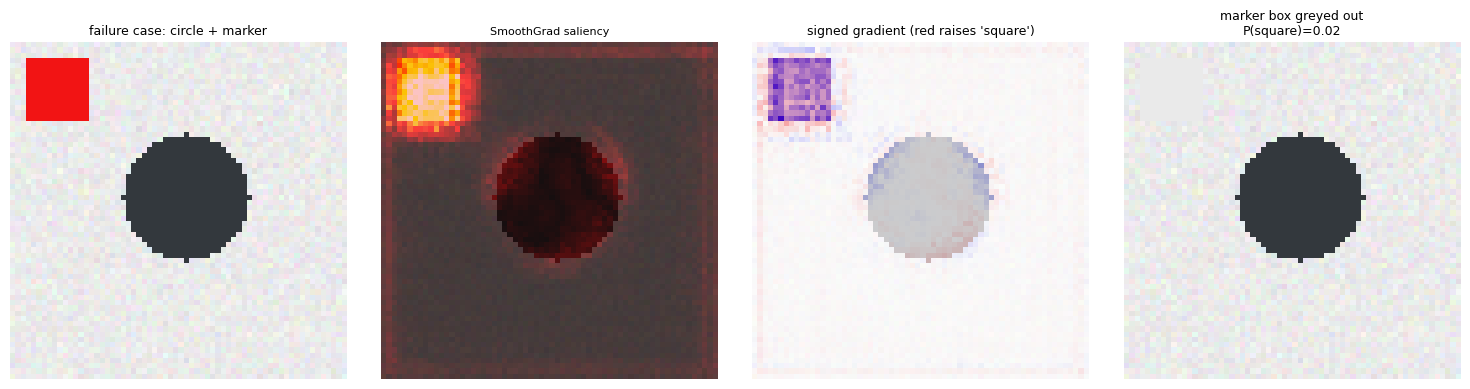


TABULAR row 1: true=1, predicted=0, P(high risk)=0.400


,value,step 0.1 std,step 0.25 std,step 0.5 std,step 1.0 std
income_k,66.076,-0.035,-0.071,-0.029,-0.011
recent_late_payments,1.000,0.070,0.070,0.070,0.070
savings_k,5.975,-0.092,-0.058,-0.028,-0.007
age,31.000,-0.110,-0.043,-0.023,-0.019
zip_proxy,0.000,0.040,0.040,0.040,0.040
app_minutes,16.113,0.033,0.036,0.043,0.039
promo_seen,1.000,0.031,0.031,0.031,0.031
loyalty_years,2.792,-0.024,-0.022,-0.022,-0.009
debt_ratio,0.724,0.011,0.004,0.008,0.026
support_tickets,0.000,0.000,0.000,0.000,0.000


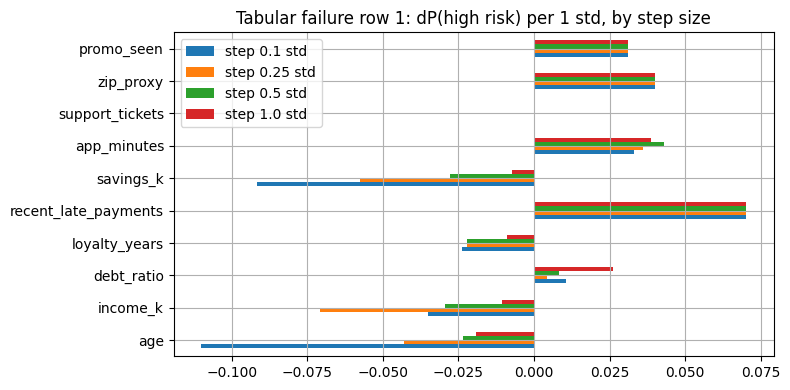

In [16]:
# NOTE: only the image failure case (first half) is scored. The tabular half is a finite-difference substitute, shown for context only.
# Event 8: explain a failure. Image failure case = a circle that carries the red marker; tabular failure case = a missed high-risk row.
i = image_failure_case
c = int(image_pred[i])
sm = saliency_map(test_imgs[[i]], n_noise=50, sigma=0.1)[0]
sg = signed_map(test_imgs[[i]], n_noise=50, sigma=0.1)[0]
print(f"IMAGE idx {i}: true={'square' if test_y[i] else 'circle'}, predicted={'square' if c else 'circle'} with P(square)={image_proba[i, 1]:.3f}, marker={test_marker[i]}")
share = region_share(sm, test_imgs[i])
print(f"SmoothGrad mass: marker box {share[0]:.0%}, shape {share[1]:.0%}, background {share[2]:.0%}")

# Intervention that tests the saliency claim: grey out ONLY the marker box, then re-predict
fixed = test_imgs[i].copy(); fixed[MARKER_BOX] = 0.92
rs = np.random.default_rng(0)
ctrl = [];
for _ in range(25):                                  # control: a same-sized box placed at random elsewhere
    y0, x0 = rs.integers(0, 52, 2); t = test_imgs[i].copy(); t[y0:y0 + 12, x0:x0 + 12] = 0.92; ctrl.append(predict_image_proba(t[None])[0, 1])
print(f"P(square): original {image_proba[i, 1]:.3f} -> marker box removed {predict_image_proba(fixed[None])[0, 1]:.3f}; "
      f"random 12x12 box removed {np.mean(ctrl):.3f} (mean of 25)")

fig, ax = plt.subplots(1, 4, figsize=(15, 3.8))
ax[0].imshow(test_imgs[i]); ax[0].axis("off"); ax[0].set_title("failure case: circle + marker", fontsize=9)
show_saliency(ax[1], test_imgs[i], sm, "SmoothGrad saliency")
lim = np.abs(sg).max(); ax[2].imshow(test_imgs[i]); ax[2].imshow(sg, cmap="bwr", vmin=-lim, vmax=lim, alpha=0.75); ax[2].axis("off")
ax[2].set_title("signed gradient (red raises 'square')", fontsize=9)
ax[3].imshow(fixed); ax[3].axis("off"); ax[3].set_title(f"marker box greyed out\nP(square)={predict_image_proba(fixed[None])[0, 1]:.2f}", fontsize=9)
plt.tight_layout(); plt.show()

# Tabular failure case: finite-difference saliency at that row, at three step sizes
r = tabular_failure_case
row = X_test.iloc[[r]]
print(f"\nTABULAR row {r}: true={int(y_test.iloc[r])}, predicted={tabular_pred[r]}, P(high risk)={tabular_proba[r]:.3f}")
sens = pd.DataFrame({f"step {fr} std": tab_saliency(row, frac=fr).iloc[0] for fr in (0.1, 0.25, 0.5, 1.0)})
sens.insert(0, "value", row.iloc[0])
display(sens.reindex(sens["step 0.25 std"].abs().sort_values(ascending=False).index).round(3))
sens.iloc[:, 1:].plot.barh(figsize=(8, 4), title=f"Tabular failure row {r}: dP(high risk) per 1 std, by step size"); plt.tight_layout(); plt.show()

### Event 8: explanation (saliency maps)

**Output:** (image, scored) SmoothGrad and signed-gradient maps for `image_failure_case` (idx 6), plus an intervention that greys out only the marker box and re-predicts. (tabular, not scored) a table of finite-difference slopes for `tabular_failure_case` (row 1), shown for context only, because saliency cannot be applied to the forest.

**Claim:** The image failure is a circle that carries the red marker and is called a square with P = 0.98. The saliency maps point at the marker (43% of the mass in the box, 9% on the shape), and greying out just that 12×12 box drops P(square) from 0.98 to 0.02, whereas removing a same-sized box at a random place leaves it at 0.96. The model made this mistake because it learned "red corner = square". Saliency cannot diagnose the tabular failure.

**Evidence quality:** *What did the method output?* Maps of |∂ logit / ∂ pixel|. *Does it answer the question?* Yes for the image, and the deletion check confirms it is causal, not just a pretty picture. *Could it mislead?* About 48% of the mass is diffuse background, but the marker stands out clearly. *What would a better method show?* For the image, saliency is already close to ideal. For the tabular failure a contribution or counterfactual method is needed (the context table shows slopes that change with the step size, e.g. `age` −0.11 → −0.02, and a near-zero slope for `debt_ratio` even though it is a very high 0.72, so slopes measure sensitivity, not contribution).

**Medal: Gold** for the image failure. The tabular failure alone would be DNF. The event allows either target, so it is scored on the image case.

## Event 9: Estimate Trustworthiness

**Question:** Should a human trust this prediction?

**Target:** Either target model

**Your task:** Use your method to argue for or against trusting one prediction. Be specific about what your method can and cannot establish.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [17]:
# NOTE: the image checks are scored. The tabular robustness and gradient-norm checks are finite-difference substitutes, shown for context only.
# Event 9: should a human trust a prediction? Three checks that saliency allows, then an honest test of whether they work.
names = list(assigned_image_cases["case_name"]); idxs = [int(i) for i in assigned_image_cases["image_index"]]
imgs = test_imgs[idxs]

# (1) is the explanation stable? vanilla vs SmoothGrad, and each vs the same map after adding tiny pixel noise
rs = np.random.default_rng(0)
noisy = np.clip(imgs + rs.normal(0, 0.02, imgs.shape).astype(np.float32), 0, 1)
van, van_n = saliency_map(imgs), saliency_map(noisy)
sm, sm_n = saliency_map(imgs, n_noise=50), saliency_map(noisy, n_noise=50)
stab = pd.DataFrame({
    "P(pred class)": [float(image_proba[i, image_pred[i]]) for i in idxs],
    "marker share (SmoothGrad)": [region_share(sm[k], imgs[k])[0] for k in range(4)],
    "vanilla: rho(x, x+noise)": [spearmanr(van[k].ravel(), van_n[k].ravel())[0] for k in range(4)],
    "SmoothGrad: rho(x, x+noise)": [spearmanr(sm[k].ravel(), sm_n[k].ravel())[0] for k in range(4)],
    "rho(vanilla, SmoothGrad)": [spearmanr(van[k].ravel(), sm[k].ravel())[0] for k in range(4)],
}, index=names).round(2)
display(stab)

# (2) tabular: how fragile is the class under small feature noise, and how steep is the local slope?
rows = []
for nm, r in zip(assigned_tabular_cases.case_name, assigned_tabular_cases.row_index_in_X_test):
    x = X_test.iloc[[int(r)]]
    xs = pd.concat([x] * 300, ignore_index=True)
    for f in ["age", "income_k", "debt_ratio", "loyalty_years", "savings_k", "app_minutes"]:
        xs[f] = xs[f] * (1 + rs.normal(0, 0.05, 300))
    p = predict_risk_proba(xs)[:, 1]
    s = tab_saliency(x).iloc[0]
    rows.append({"case": nm, "P(high)": float(tabular_proba[int(r)]), "P range under 5% noise": f"{p.min():.2f}-{p.max():.2f}",
                 "class flips under noise": float(((p > 0.5) != (tabular_proba[int(r)] > 0.5)).mean()),
                 "largest |slope| (per std)": float(s.abs().max()), "steepest feature": s.abs().idxmax()})
display(pd.DataFrame(rows).round(3))

# (3) does any saliency-based signal predict WRONG predictions on the whole test set?
sal_all = saliency_map(test_imgs)                                        # vanilla, all 320 images
img_err = (image_pred != test_y).astype(int)
img_marker_share = np.array([region_share(sal_all[k], test_imgs[k])[0] for k in range(len(test_imgs))])
img_conf = image_proba.max(1)
ts = tab_saliency(X_test)
tab_err = (tabular_pred != y_test.values).astype(int)
tab_gnorm = np.sqrt((ts ** 2).sum(1)).values
tab_conf = np.abs(tabular_proba - 0.5)
auc = pd.DataFrame({"AUC for detecting errors (0.5 = useless)": {
    "image: saliency share in marker box": roc_auc_score(img_err, img_marker_share),
    "image: total saliency magnitude": roc_auc_score(img_err, sal_all.reshape(len(sal_all), -1).sum(1)),
    "image: -confidence   [not saliency]": roc_auc_score(img_err, -img_conf),
    "tabular: gradient norm (sensitivity)": roc_auc_score(tab_err, tab_gnorm),
    "tabular: -|P-0.5|   [not saliency]": roc_auc_score(tab_err, -tab_conf)}}).round(3)
display(auc)
print("Image test accuracy:", round(float(1 - img_err.mean()), 3), "| marker-box share of saliency: correct images", round(float(img_marker_share[img_err == 0].mean()), 2),
      "vs wrong images", round(float(img_marker_share[img_err == 1].mean()), 2))

,P(pred class),marker share (SmoothGrad),"vanilla: rho(x, x+noise)","SmoothGrad: rho(x, x+noise)","rho(vanilla, SmoothGrad)"
shortcut_probe,0.98,0.45,0.80,0.97,0.77
reference_square,0.99,0.31,0.83,0.97,0.62
contrast_square,0.94,0.03,0.88,0.99,0.89
failure_case,0.98,0.44,0.80,0.97,0.78


,case,P(high),P range under 5% noise,class flips under noise,largest |slope| (per std),steepest feature
0,local_case,0.499,0.45-0.53,0.55,0.121,recent_late_payments
1,low_case,0.022,0.02-0.05,0.00,0.028,zip_proxy
2,high_case,0.789,0.75-0.83,0.00,0.052,zip_proxy
3,failure_case,0.400,0.38-0.45,0.00,0.071,income_k


,AUC for detecting errors (0.5 = useless)
image: saliency share in marker box,0.632
image: total saliency magnitude,0.374
image: -confidence [not saliency],0.769
tabular: gradient norm (sensitivity),0.658
tabular: -|P-0.5| [not saliency],0.708


Image test accuracy: 0.494 | marker-box share of saliency: correct images 0.23 vs wrong images 0.23


### Event 9: explanation (saliency maps)

**Output:** (image, scored) a stability table for the four assigned image cases (vanilla and SmoothGrad maps compared with themselves after small pixel noise, and with each other), and AUCs showing whether saliency-based signals can pick out the wrong predictions on all 320 test images. (tabular, not scored) a robustness check of the four tabular cases, shown for context only, because saliency cannot be applied to the forest.

**Claim:** A human should **not** trust the image shortcut probe (a circle predicted square with P = 0.98): 45% of its SmoothGrad saliency sits on the red marker (3.5% of the pixels) and only 8% on the shape, so the model is answering from the wrong evidence.

**Evidence quality:** *What did the method output?* Maps, region shares and a stability table. *Does it answer the question?* Only for individual predictions where the evidence is visibly illegitimate. SmoothGrad maps are far more stable than vanilla ones (rank correlation under tiny noise 0.97–0.99 vs 0.80–0.88), so the SmoothGrad diagnosis is reliable. *Could it mislead?* Yes. On the marker-free `contrast_square` the map lights up the shape (72% of mass), which would reassure a human that the model is "looking at the shape", although the prediction (circle for a square) is wrong. As an error detector, saliency is weak: the marker-box share gives AUC 0.63 against 0.77 for plain prediction confidence, and the share is identical for correct and wrong images (0.23 vs 0.23). *What would a better method show?* Calibrated uncertainty (confidence, ensembles) for "how likely is this wrong", with saliency used only to spot illegitimate evidence.

**Medal: Silver** (scored on the image model only)

## Event 10: Reverse Engineer the Model

**Question:** What strategy has each model learned?

**Target:** Both target models

**Your task:** Synthesize evidence across events. A single output is usually not enough; explain what your method revealed and what remains unknown.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

marker box  shape  background  predicted square
label  marker                                                    
circle marker           0.41   0.18        0.42               1.0
       no marker        0.03   0.66        0.32               0.0
square marker           0.37   0.19        0.44               1.0
       no marker        0.03   0.69        0.29               0.0

Mean share of saliency inside the marker box: 22% (the box is 3.5% of the pixels); on the shape: 41%
Rule 'marker => square' agrees with the CNN on 100.0% of test images; the CNN agrees with the true shape on 49.4%


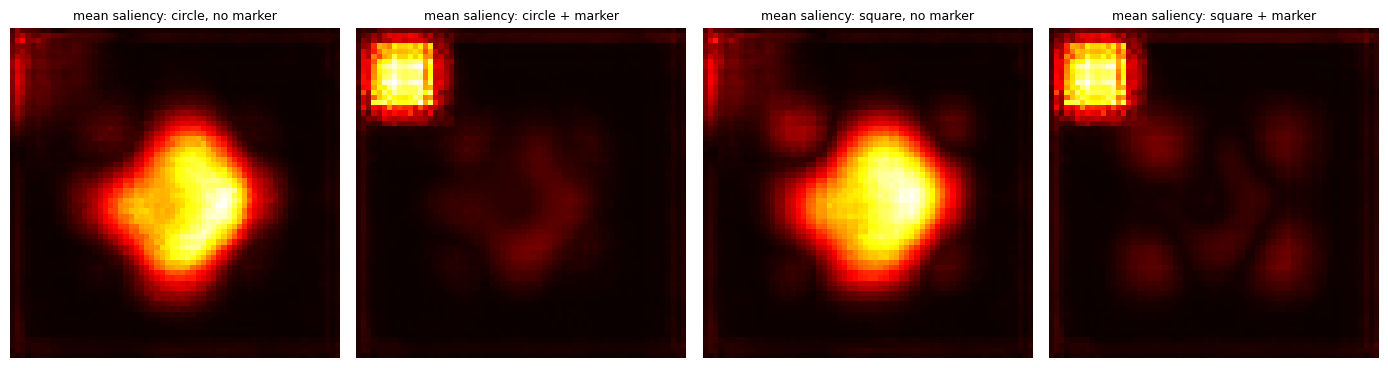

,mean |saliency| (dP per 1 std),mean signed saliency,share of rows where it is ~0,reading
debt_ratio,0.071,0.069,0.009,higher -> riskier
zip_proxy,0.058,0.058,0.000,higher -> riskier
recent_late_payments,0.040,0.039,0.007,higher -> riskier
savings_k,0.039,-0.035,0.020,higher -> safer
income_k,0.036,-0.033,0.023,higher -> safer
loyalty_years,0.030,-0.028,0.017,higher -> safer
app_minutes,0.016,-0.005,0.028,higher -> safer
promo_seen,0.014,0.014,0.000,higher -> riskier
age,0.013,-0.003,0.003,higher -> safer
support_tickets,0.006,0.005,0.015,higher -> riskier


Spearman of the feature ranking, step 0.25 vs 0.1 / 0.5 / 1.0 std: [np.float64(0.95), np.float64(0.98), np.float64(0.98)]


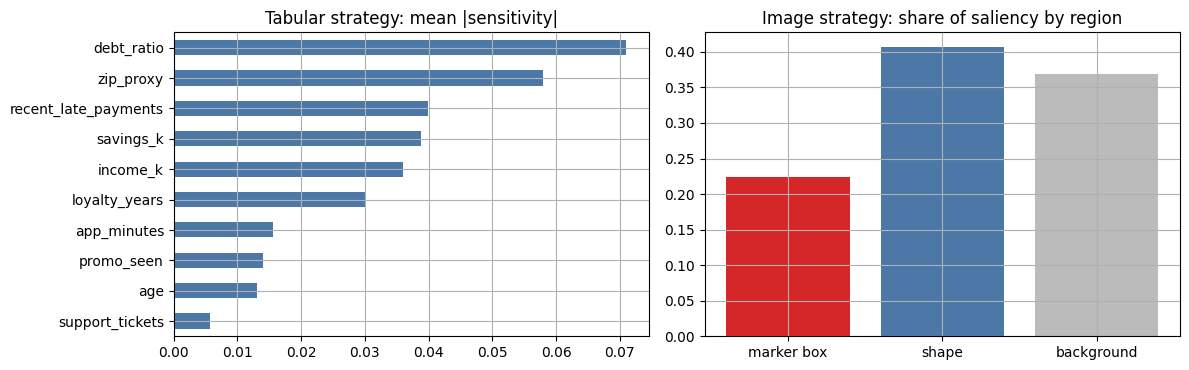

In [18]:
# NOTE: the image analysis is scored. The tabular sensitivity ranking is a finite-difference substitute, shown for context only.
# Event 10: reverse-engineer each model's strategy by pooling saliency over many inputs.
# ---------------- Image model: aggregate saliency by group, over the whole balanced test set
sal_all = saliency_map(test_imgs, n_noise=20, sigma=0.1)                 # SmoothGrad over all 320 test images
shares = np.array([region_share(sal_all[k], test_imgs[k]) for k in range(len(test_imgs))])
grp = pd.DataFrame(shares, columns=["marker box", "shape", "background"])
grp["label"] = np.where(test_y == 1, "square", "circle"); grp["marker"] = np.where(test_marker == 1, "marker", "no marker")
grp["predicted square"] = (image_pred == 1).astype(float)
display(grp.groupby(["label", "marker"]).mean(numeric_only=True).round(2))
print(f"Mean share of saliency inside the marker box: {shares[:, 0].mean():.0%} (the box is 3.5% of the pixels); on the shape: {shares[:, 1].mean():.0%}")

# Does saliency on the *marker location* control the prediction? Rule: 'marker present => square'
rule = test_marker.astype(int)
print(f"Rule 'marker => square' agrees with the CNN on {(rule == image_pred).mean():.1%} of test images; "
      f"the CNN agrees with the true shape on {(test_y == image_pred).mean():.1%}")
mean_map = {k: sal_all[(test_marker == m) & (test_y == l)].mean(0) for k, (l, m) in
            {"circle, no marker": (0, 0), "circle + marker": (0, 1), "square, no marker": (1, 0), "square + marker": (1, 1)}.items()}
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, (k, m) in zip(axes, mean_map.items()):
    ax.imshow(m, cmap="hot"); ax.axis("off"); ax.set_title(f"mean saliency: {k}", fontsize=9)
plt.tight_layout(); plt.show()

# ---------------- Tabular model: pool the finite-difference saliency over the whole test set
ts = tab_saliency(X_test)
glob = pd.DataFrame({"mean |saliency| (dP per 1 std)": ts.abs().mean(), "mean signed saliency": ts.mean(),
                     "share of rows where it is ~0": (ts.abs() < 1e-9).mean()}).sort_values("mean |saliency| (dP per 1 std)", ascending=False)
glob["reading"] = np.where(glob["mean signed saliency"] > 0, "higher -> riskier", "higher -> safer")
display(glob.round(3))
# how robust is this ranking to the step size?
rk = pd.DataFrame({fr: tab_saliency(X_test, frac=fr).abs().mean() for fr in (0.1, 0.25, 0.5, 1.0)})
print("Spearman of the feature ranking, step 0.25 vs 0.1 / 0.5 / 1.0 std:",
      [round(spearmanr(rk[0.25], rk[o])[0], 2) for o in (0.1, 0.5, 1.0)])

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
glob["mean |saliency| (dP per 1 std)"][::-1].plot.barh(ax=ax[0], color="#4c78a8"); ax[0].set_title("Tabular strategy: mean |sensitivity|")
ax[1].bar(["marker box", "shape", "background"], shares.mean(0), color=["#d62728", "#4c78a8", "#bbbbbb"]); ax[1].set_title("Image strategy: share of saliency by region")
plt.tight_layout(); plt.show()

### Event 10: explanation (saliency maps)

**Output:** (image, scored) mean SmoothGrad saliency over all 320 balanced test images, split into circle/square × marker/no marker, with the share of saliency mass in the marker box, on the shape and on the background, plus the predicted-square rate per group. (tabular, not scored) a finite-difference sensitivity ranking, shown for context only, because saliency cannot be applied to the forest.

**Claim:** Saliency can profile only the image model. That model ignores shape and reads the red corner marker: marker present → predicted square 100% of the time; marker absent → predicted circle 100% of the time, for both circles and squares (accuracy 0.49). A one-line rule "marker => square" reproduces the CNN on 100% of test images. Saliency cannot reverse-engineer the tabular model's strategy.

**Evidence quality:** *What did the method output?* Region shares of the saliency maps. *Does it answer the question?* For the image model, only partly. On marker-free images 66–69% of the saliency sits on the shape, which suggests the shape is being used, yet the model calls every one of those images a circle whatever the shape. The marker rule and the accuracy of 0.49 are what reveal the real strategy. *Could it mislead?* Yes, as above. *What would a better method show?* A baseline-relative attribution or a counterfactual test shows that the absence of the marker is itself the decisive evidence. For the tabular model, SHAP, permutation importance and partial dependence would be needed (the substitute ranks `debt_ratio` > `zip_proxy` > `recent_late_payments`, but that is not saliency).

**Medal: Silver** (half of the question, the image model, is answered, and needed a behavioural check)

# Final Model Profile

After all ten events, write a short synthesis.

**Tabular model strategy:**  
Which features seem important? Did you find global effects, local effects, interactions, or suspicious proxies? What can your method support?

**Image model strategy:**  
Does the classifier appear to use the shape, the red marker, or both? What evidence supports that claim?

**Your method's decathlon profile:**  
Where did your method perform well? Where did it fail? What kind of explanation question is it best suited for?

**Open questions:**  
What would you want to compare with classmates who used other methods?
